# Projet : IA for HumanForYou

L'idée de ce projet est de faire suite à la validation éthique (voir livrable éthique).
Nous allons donc mettre en place un pipeline, comprenant plusieurs étapes :
- Création de 3 jeux de données :
***Courbe d'apprentissage, données aléatoires***
    - Avec un jeu d'apprentissage (60%)
    - Avec un jeu de validation (20%)
    - Avec un jeu de test (20%)
- Pré-traitement :
    - Valeurs manquantes, aberrantes, éronnées (erreur de type par exemple)
    - Standardisation (normalisation)
- Choix du modèle et des caractéristiques :
    - Modèle 1
    - Modèle 2
    - Modèle 3
- Apprentissage sur jeu d'apprentissage
- Validation sur jeu de validation
- Evaluation finale sur jeu de test


In [31]:
# Variable to choose whether to drop missing data or replace it with the median or mean
dropData = False 

## Installation et Import

In [32]:
%pip install --upgrade pip
%pip install pandas
%pip install Matplotlib
%pip install SNS seaborn
%pip install numpy
%pip install scikit-learn
%pip install missingno

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tarfile
import os
from sklearn.preprocessing import LabelEncoder,StandardScaler
import missingno as msno
import scipy.stats as stats

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Import des données

In [33]:

import seaborn as sns
import matplotlib.pyplot as plt
import csv

# Configuring display settings
plt.rcParams['figure.figsize'] = (12, 9)
sns.set_theme()
sns.set_context('talk')
np.set_printoptions(threshold=20, precision=2, suppress=True)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)

# Extract all .csv files
general_data_file_path = '../Data/general_data.csv'
employee_survey_data_file_path = '../Data/employee_survey_data.csv'
manager_survey_data_file_path = '../Data/manager_survey_data.csv'
in_data_file_path = '../Data/in_time.csv'
out_data_file_path = '../Data/out_time.csv'

# Load the dataset
general_data = pd.read_csv(general_data_file_path)
employee_survey_data = pd.read_csv(employee_survey_data_file_path)
manager_survey_data = pd.read_csv(manager_survey_data_file_path)

# Handling malformatted CSV files for in_time and out_time
in_data = pd.read_csv(in_data_file_path, sep=",", engine="python", quoting=3)
out_data = pd.read_csv(out_data_file_path, sep=",", engine="python", quoting=3)

in_data.columns = (in_data.columns.str.strip().str.replace('"', '', regex=False))
out_data.columns = (out_data.columns.str.strip().str.replace('"', '', regex=False))

for col in in_data.columns:
    in_data[col] = in_data[col].astype(str).str.strip().str.replace('"', '', regex=False)

for col in out_data.columns:
    out_data[col] = out_data[col].astype(str).str.strip().str.replace('"', '', regex=False)

# Reshape in_time and out_time data from wide to long format to facilitate analysis
in_data = in_data.melt(id_vars="EmployeeID", var_name="date", value_name="in_time")
out_data = out_data.melt(id_vars="EmployeeID", var_name="date", value_name="out_time")

# Remove rows with missing or invalid time entries
in_data = in_data[in_data["in_time"].notna() &(in_data["in_time"] != "NA") &(in_data["in_time"] != "nan")]
out_data = out_data[out_data["out_time"].notna() &(out_data["out_time"] != "NA") &(out_data["out_time"] != "nan")]

# Applying types to data
in_data["EmployeeID"] = pd.to_numeric(in_data["EmployeeID"], errors="coerce")
out_data["EmployeeID"] = pd.to_numeric(out_data["EmployeeID"], errors="coerce")

in_data["in_time"] = pd.to_datetime(in_data["in_time"], errors="coerce")
out_data["out_time"] = pd.to_datetime(out_data["out_time"], errors="coerce")

# Merge In and Out data on EmployeeID and date to calculate time-based features
time_data = in_data.merge(out_data, on=["EmployeeID", "date"], how="inner")

# Features arrival, departure and worked hours in float format (hours)
time_data["arrival_float"] = (time_data["in_time"].dt.hour + time_data["in_time"].dt.minute / 60 + time_data["in_time"].dt.second / 3600)
time_data["departure_float"] = (time_data["out_time"].dt.hour + time_data["out_time"].dt.minute / 60 + time_data["out_time"].dt.second / 3600)
time_data["worked_float"] = ((time_data["out_time"] - time_data["in_time"]).dt.total_seconds() / 3600)

# Average arrival, departure and worked hours per employee
employee_time_features_data = time_data.groupby("EmployeeID", as_index=False).agg(AverageArrival=("arrival_float", "mean"),AverageDeparture=("departure_float", "mean"),AverageWorkedHours=("worked_float", "mean"),)

# Check if the data is loaded correctly
print("----------------------------------------------------------------------------")
print("General Data Head:")
print(general_data.head())
print("----------------------------------------------------------------------------")
print("Employee Survey Data Head:")
print(employee_survey_data.head())
print("----------------------------------------------------------------------------")
print("Manager Survey Data Head:")
print(manager_survey_data.head())
print("----------------------------------------------------------------------------")
print("Employee time features Data Head:")
print(employee_time_features_data.head())
print("----------------------------------------------------------------------------")

----------------------------------------------------------------------------
General Data Head:
   Age Attrition     BusinessTravel              Department  DistanceFromHome  \
0   51        No      Travel_Rarely                   Sales                 6   
1   31       Yes  Travel_Frequently  Research & Development                10   
2   32        No  Travel_Frequently  Research & Development                17   
3   38        No         Non-Travel  Research & Development                 2   
4   32        No      Travel_Rarely  Research & Development                10   

   Education EducationField  EmployeeCount  EmployeeID  Gender  JobLevel  \
0          2  Life Sciences              1           1  Female         1   
1          1  Life Sciences              1           2  Female         1   
2          4          Other              1           3    Male         4   
3          5  Life Sciences              1           4    Male         3   
4          1        Medical          

## Selection des données

Dans un soucis ethique et morale, nous avons décidé de ne pas selectionner certaines données, afin d'eviter le plus de biais possible lors de l'analyse

In [34]:
# Drop collumns with unethical data for analysis, such as Age, Gender, MaritalStatus, and #TODO EducationField which can lead to bias in the analysis and may not be relevant for the analysis of employee attrition.
general_data = general_data.drop(columns=['Age', 'Gender', 'MaritalStatus'])

Nous allons également filtrer les données qui n'influenceront pas l'analyse, comme le temps de travail qui est de 8h pour tout les employées et le fait d'etre majeur par exemple

In [35]:
# Drop collumns with non interresting values for analysis, such as EmployeeCount, Over18 and StandardHours which are the same for all employees and do not provide any useful information for analysis.
general_data = general_data.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'])

## Filtrage des données

Maintenant que nous avons filtré les données, nous allons vérifier les valeurs manquantes, aberrantes, éronnées, cohérentes et dupliquées.

In [36]:
print("----------------------------------------------------------------------------")
print("General Data Information:")
print(general_data.info())
print("----------------------------------------------------------------------------")
print("General Data Description:")
print(general_data.describe())
print("----------------------------------------------------------------------------")
print("General Data Missing Values:")
print(general_data.isnull().sum())
print("----------------------------------------------------------------------------")
print()

print("----------------------------------------------------------------------------")
print("Employee Survey Data Information:")
print(employee_survey_data.info())
print("----------------------------------------------------------------------------")
print("Employee Survey Data Description:")
print(employee_survey_data.describe())
print("----------------------------------------------------------------------------")
print("Employee Survey Data Missing Values:")
print(employee_survey_data.isnull().sum())
print("----------------------------------------------------------------------------")
print()

print("----------------------------------------------------------------------------")
print("Manager Survey Data Information:")
print(manager_survey_data.info())
print("----------------------------------------------------------------------------")
print("Manager Survey Data Description:")
print(manager_survey_data.describe())
print("----------------------------------------------------------------------------")
print("Manager Survey Data Missing Values:")
print(manager_survey_data.isnull().sum())
print("----------------------------------------------------------------------------")
print()

print("----------------------------------------------------------------------------")
print("Employee Time Features Data Information:")
print(employee_time_features_data.info())
print("----------------------------------------------------------------------------")
print("Employee Time Features Data Description:")
print(employee_time_features_data.describe())
print("----------------------------------------------------------------------------")
print("Employee Time Features Data Missing Values:")
print(employee_time_features_data.isnull().sum())
print("----------------------------------------------------------------------------")
print()

----------------------------------------------------------------------------
General Data Information:
<class 'pandas.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Attrition                4410 non-null   str    
 1   BusinessTravel           4410 non-null   str    
 2   Department               4410 non-null   str    
 3   DistanceFromHome         4410 non-null   int64  
 4   Education                4410 non-null   int64  
 5   EducationField           4410 non-null   str    
 6   EmployeeID               4410 non-null   int64  
 7   JobLevel                 4410 non-null   int64  
 8   JobRole                  4410 non-null   str    
 9   MonthlyIncome            4410 non-null   int64  
 10  NumCompaniesWorked       4391 non-null   float64
 11  PercentSalaryHike        4410 non-null   int64  
 12  StockOptionLevel         4410 non-null  

### Valeurs manquantes

In [37]:
# CHECKING THE IMPACT OF MISSING VALUES ON THE MEAN OF THE "TotalWorkingYears" COLUMN

# Only for testing purposes, to see the impact of missing values on the mean of the "TotalWorkingYears" column. We will drop the missing values, replace them with the median and replace them with a constant value (50) to see the difference in the mean. """
# c = general_data["TotalWorkingYears"].dropna()
# a = general_data["TotalWorkingYears"].fillna(general_data["TotalWorkingYears"].median())
# b = general_data["TotalWorkingYears"].fillna(50)

# print("Mean after dropping missing values:", c.mean())
# print("Mean after replacing with median:", a.mean())
# print("Mean after replacing with 50:", b.mean())


----------------------------------------------------------------------------
NumCompaniesWorked
1.00    1558
0.00     586
3.00     474
2.00     438
4.00     415
7.00     222
6.00     208
5.00     187
9.00     156
8.00     147
Name: count, dtype: int64
----------------------------------------------------------------------------
TotalWorkingYears
10.00    605
6.00     375
8.00     307
9.00     287
5.00     264
        ... 
34.00     15
37.00     12
35.00      9
40.00      6
38.00      3
Name: count, Length: 40, dtype: int64
----------------------------------------------------------------------------

----------------------------------------------------------------------------
EnvironmentSatisfaction
3.00    1350
4.00    1334
2.00     856
1.00     845
Name: count, dtype: int64
----------------------------------------------------------------------------
JobSatisfaction
4.00    1367
3.00    1323
1.00     860
2.00     840
Name: count, dtype: int64
--------------------------------------------

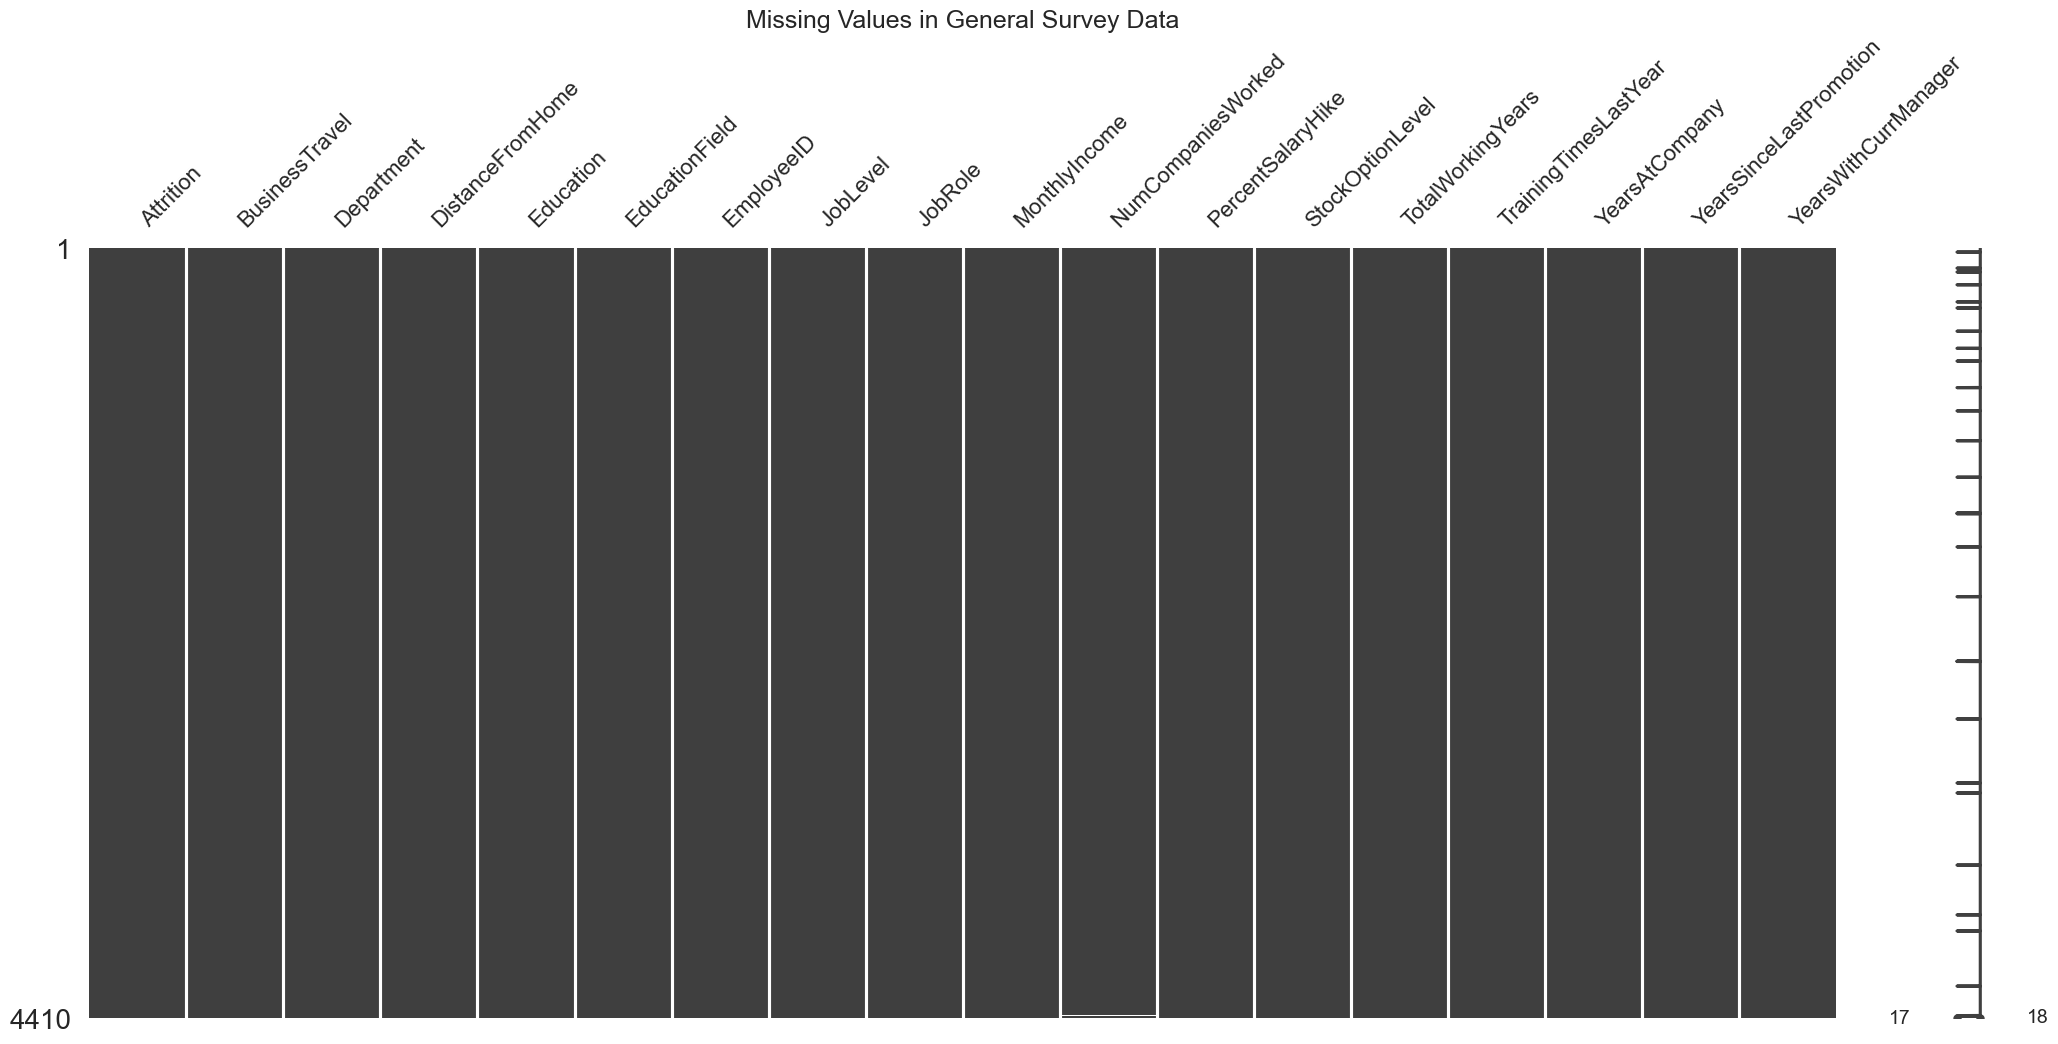

----------------------------------------------------------------------------
General Data Missing Values:
Attrition                  0
BusinessTravel             0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
EmployeeID                 0
JobLevel                   0
JobRole                    0
MonthlyIncome              0
NumCompaniesWorked         0
PercentSalaryHike          0
StockOptionLevel           0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64
----------------------------------------------------------------------------



C:\Users\axel0\AppData\Local\Temp\ipykernel_33796\679894782.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  general_data_categorical_columns = general_data.select_dtypes(include=['object']).columns


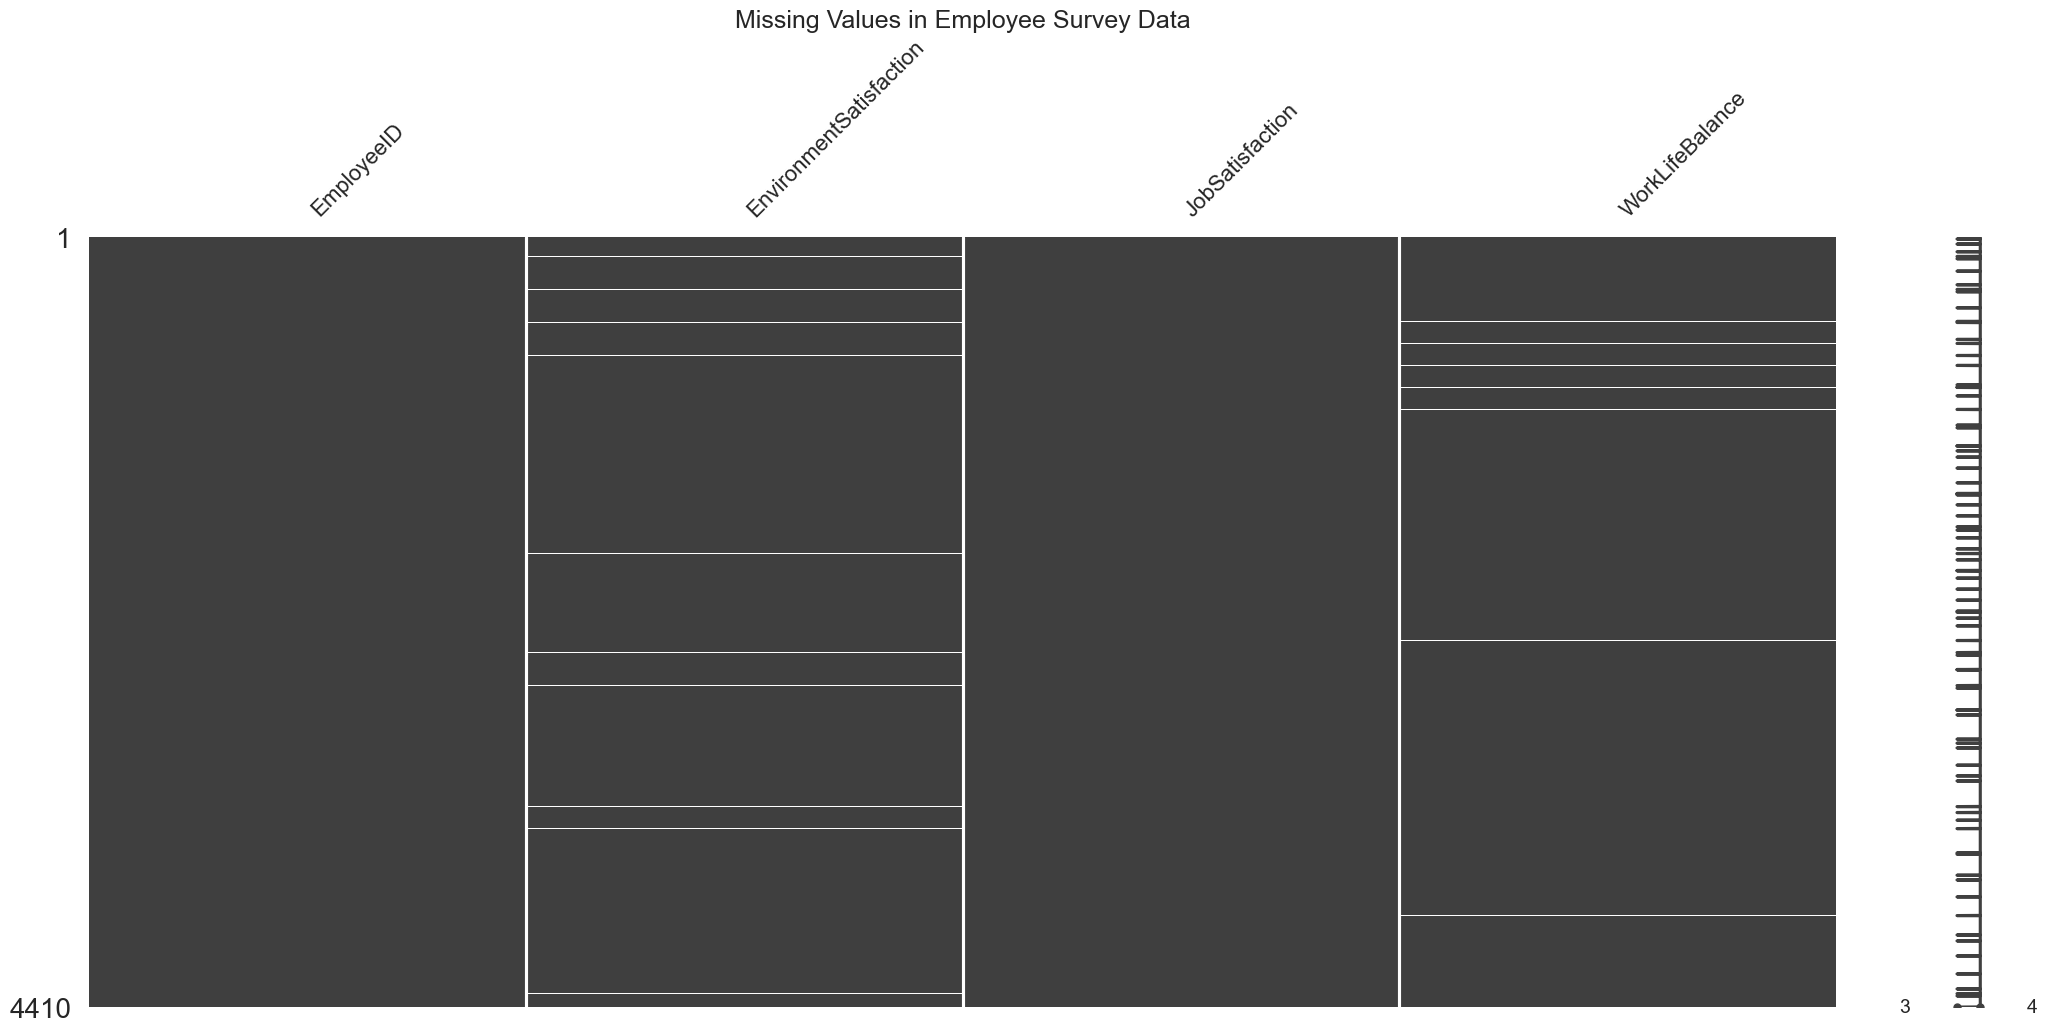

----------------------------------------------------------------------------
Employee Survey Data Missing Values:
EmployeeID                 0
EnvironmentSatisfaction    0
JobSatisfaction            0
WorkLifeBalance            0
dtype: int64
----------------------------------------------------------------------------
Final verification of missing values after filling them:
----------------------------------------------------------------------------
General Data Duplicates:
0
----------------------------------------------------------------------------
Employee Survey Data Duplicates:
0
----------------------------------------------------------------------------



In [38]:
import matplotlib.pyplot as plt
import missingno as msno

print("----------------------------------------------------------------------------")
print(general_data["NumCompaniesWorked"].value_counts())
print("----------------------------------------------------------------------------")
print(general_data["TotalWorkingYears"].value_counts())
print("----------------------------------------------------------------------------")
print()
print("----------------------------------------------------------------------------")
print(employee_survey_data["EnvironmentSatisfaction"].value_counts())
print("----------------------------------------------------------------------------")
print(employee_survey_data["JobSatisfaction"].value_counts())
print("----------------------------------------------------------------------------")
print(employee_survey_data["WorkLifeBalance"].value_counts())
print("----------------------------------------------------------------------------")

# Visualize missing data
msno.matrix(general_data)
plt.title("Missing Values in General Survey Data")
plt.show()

general_data_numerical_columns = general_data.select_dtypes(include=['float64', 'int64']).columns
general_data_categorical_columns = general_data.select_dtypes(include=['object']).columns

# Fill missing values in general_data with the mode
if dropData:
    general_data = general_data.dropna()
else:
    general_data[general_data_numerical_columns] = general_data[general_data_numerical_columns].fillna(general_data[general_data_numerical_columns].median())
    general_data[general_data_categorical_columns] = general_data[general_data_categorical_columns].fillna(general_data[general_data_categorical_columns].mode().iloc[0])

print("----------------------------------------------------------------------------")
print("General Data Missing Values:")
print(general_data.isnull().sum())
print("----------------------------------------------------------------------------")
print()

msno.matrix(employee_survey_data)
plt.title("Missing Values in Employee Survey Data")
plt.show()

employee_survey_data_numerical_columns = employee_survey_data.select_dtypes(include=['float64', 'int64']).columns
employee_survey_data_categorical_columns = employee_survey_data.select_dtypes(include=['object']).columns

# Fill missing values in employee_survey_data with the mode
if dropData:
    employee_survey_data = employee_survey_data.dropna()
else:
    employee_survey_data[employee_survey_data_numerical_columns] = employee_survey_data[employee_survey_data_numerical_columns].fillna(employee_survey_data[employee_survey_data_numerical_columns].median())

print("----------------------------------------------------------------------------")
print("Employee Survey Data Missing Values:")
print(employee_survey_data.isnull().sum())
print("----------------------------------------------------------------------------")

# No missing value in manager_survey_data and employee_time_features_data so we don't need to fill them

print("Final verification of missing values after filling them:")
# Check for duplicates in general_data and employee_survey_data 
print("----------------------------------------------------------------------------")
print("General Data Duplicates:")
print(general_data.duplicated().sum())
print("----------------------------------------------------------------------------")
print("Employee Survey Data Duplicates:")
print(employee_survey_data.duplicated().sum())
print("----------------------------------------------------------------------------")
print()



## Mise en relation des CSV

Maintenant que nous n'avons que les valeurs que nous souhaitons garder dans les CSV, on peut les joindre

In [39]:
import pandas as pd

print("Nombre de lignes et de colonnes dans general_data:", general_data.shape)
print("Nombre de lignes et de colonnes dans employee_survey_data:", employee_survey_data.shape)
print("Nombre de lignes et de colonnes dans manager_survey_data:", manager_survey_data.shape)
print("Nombre de lignes et de colonnes dans employee_time_features_data:", employee_time_features_data.shape)

# Join general_data, employee_survey_data and manager_survey_data on EmployeeID
data = pd.merge(general_data, employee_survey_data, on='EmployeeID', how='inner')
data = pd.merge(data, manager_survey_data, on='EmployeeID', how='inner')
data = pd.merge(data, employee_time_features_data, on='EmployeeID', how='inner')

print("Nombre de lignes et de colonnes après la jointure:", data.shape)

Nombre de lignes et de colonnes dans general_data: (4410, 18)
Nombre de lignes et de colonnes dans employee_survey_data: (4410, 4)
Nombre de lignes et de colonnes dans manager_survey_data: (4410, 3)
Nombre de lignes et de colonnes dans employee_time_features_data: (4410, 4)
Nombre de lignes et de colonnes après la jointure: (4410, 26)


In [40]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Attrition                4410 non-null   str    
 1   BusinessTravel           4410 non-null   str    
 2   Department               4410 non-null   str    
 3   DistanceFromHome         4410 non-null   int64  
 4   Education                4410 non-null   int64  
 5   EducationField           4410 non-null   str    
 6   EmployeeID               4410 non-null   int64  
 7   JobLevel                 4410 non-null   int64  
 8   JobRole                  4410 non-null   str    
 9   MonthlyIncome            4410 non-null   int64  
 10  NumCompaniesWorked       4410 non-null   float64
 11  PercentSalaryHike        4410 non-null   int64  
 12  StockOptionLevel         4410 non-null   int64  
 13  TotalWorkingYears        4410 non-null   float64
 14  TrainingTimesLastYear    4410 non-n

<class 'pandas.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Attrition                4410 non-null   str    
 1   BusinessTravel           4410 non-null   str    
 2   Department               4410 non-null   str    
 3   DistanceFromHome         4410 non-null   int64  
 4   Education                4410 non-null   str    
 5   EducationField           4410 non-null   str    
 6   EmployeeID               4410 non-null   int64  
 7   JobLevel                 4410 non-null   str    
 8   JobRole                  4410 non-null   str    
 9   MonthlyIncome            4410 non-null   int64  
 10  NumCompaniesWorked       4410 non-null   float64
 11  PercentSalaryHike        4410 non-null   int64  
 12  StockOptionLevel         4410 non-null   int64  
 13  TotalWorkingYears        4410 non-null   float64
 14  TrainingTimesLastYear    4410 non-n

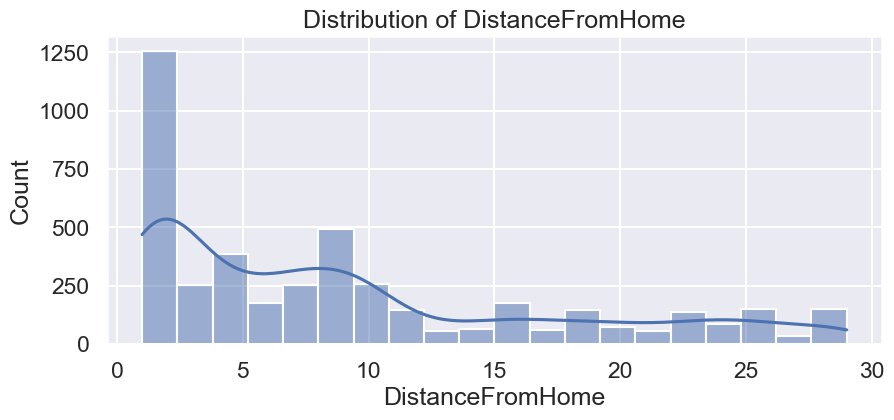

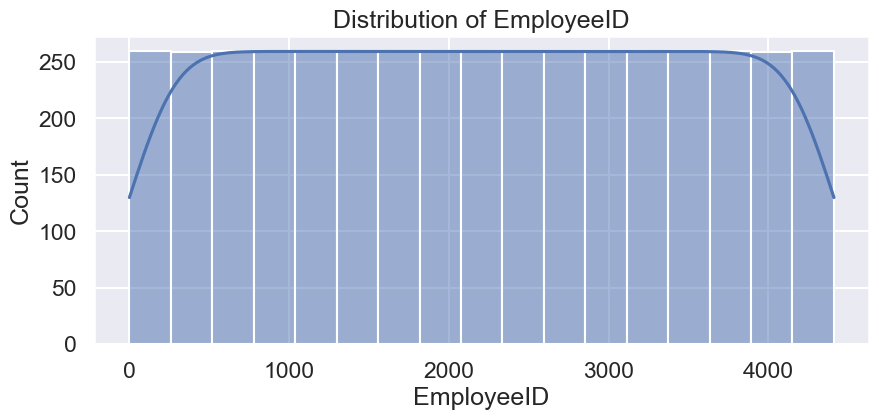

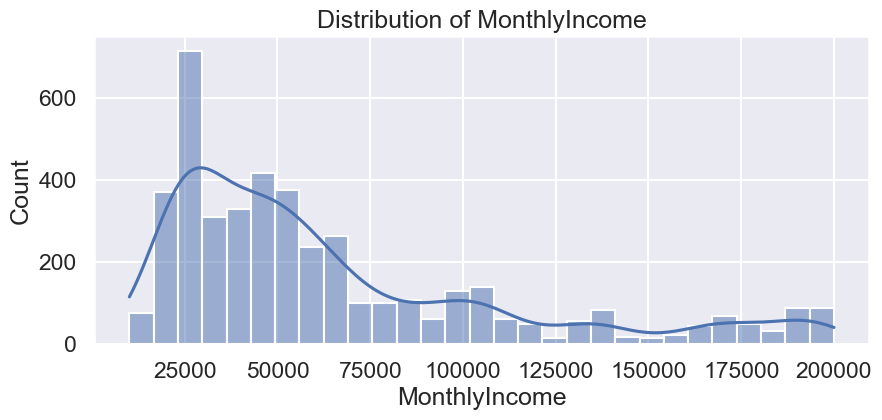

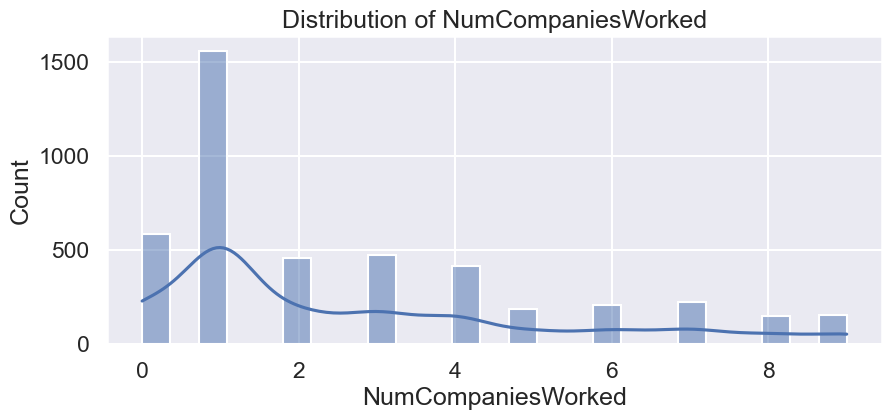

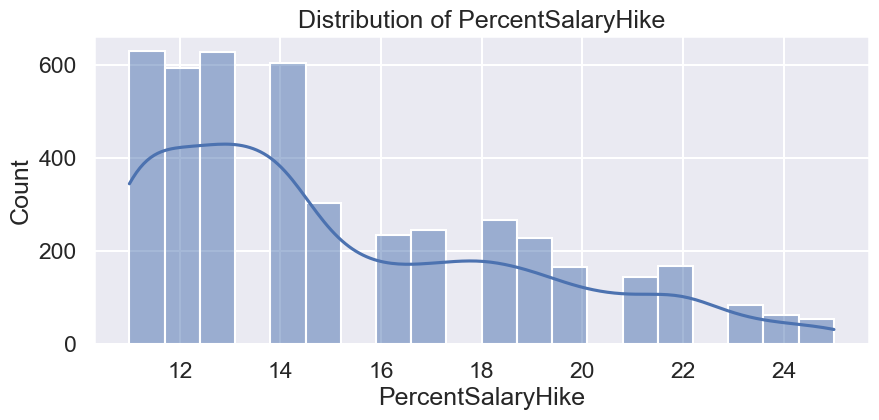

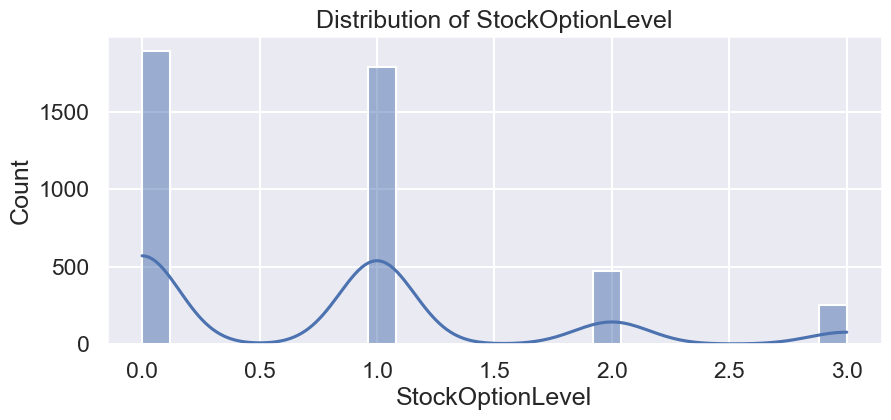

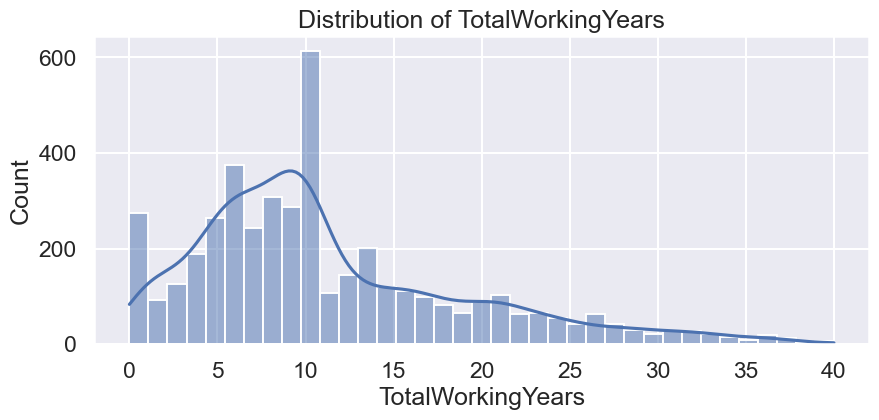

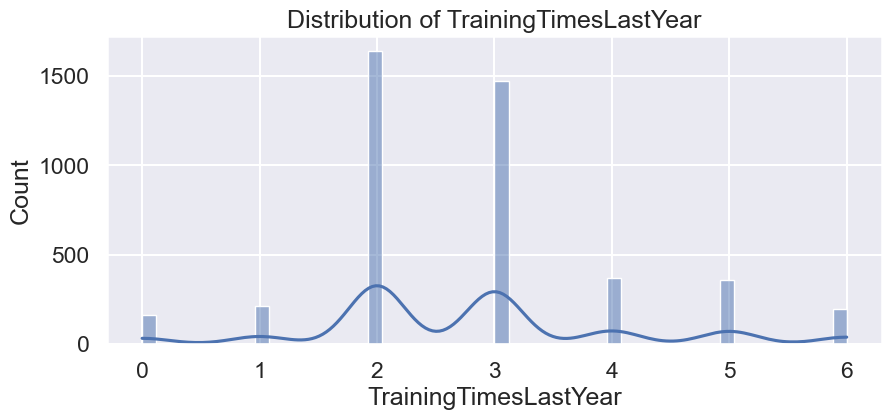

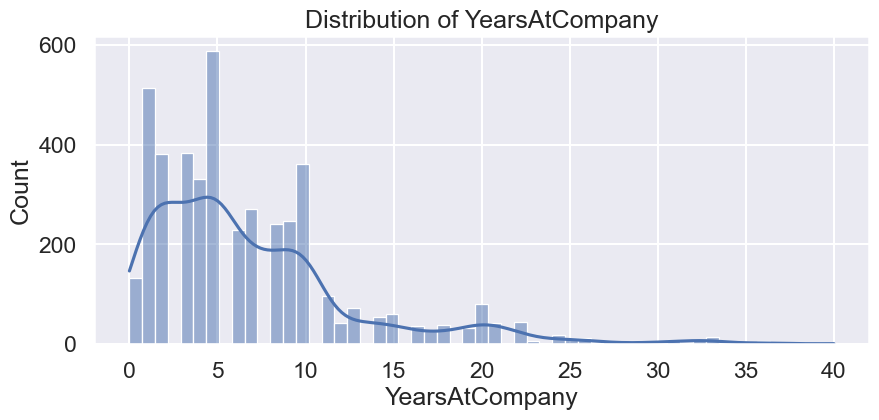

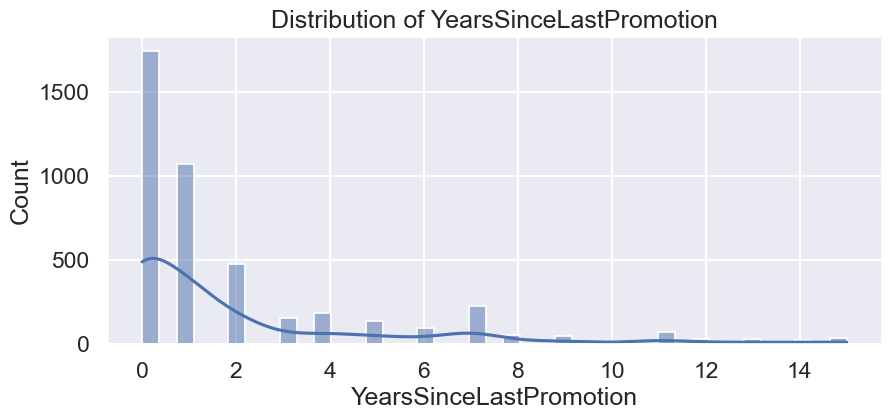

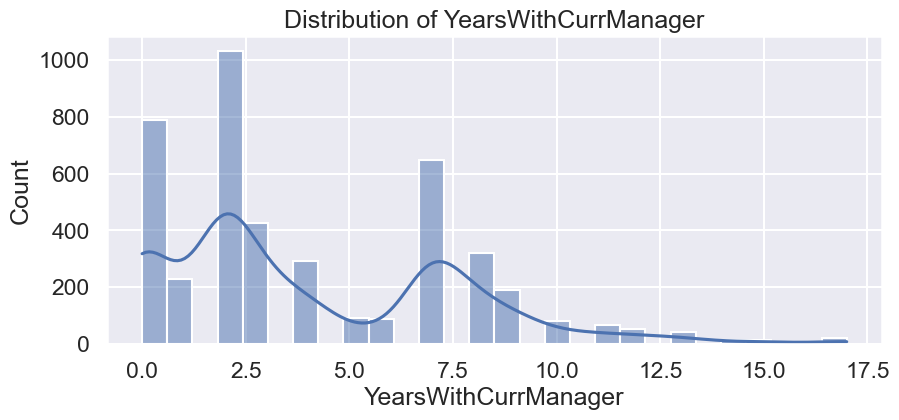

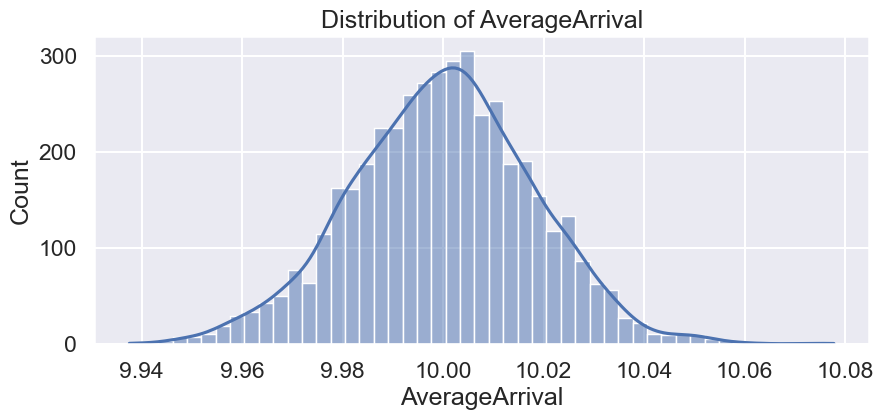

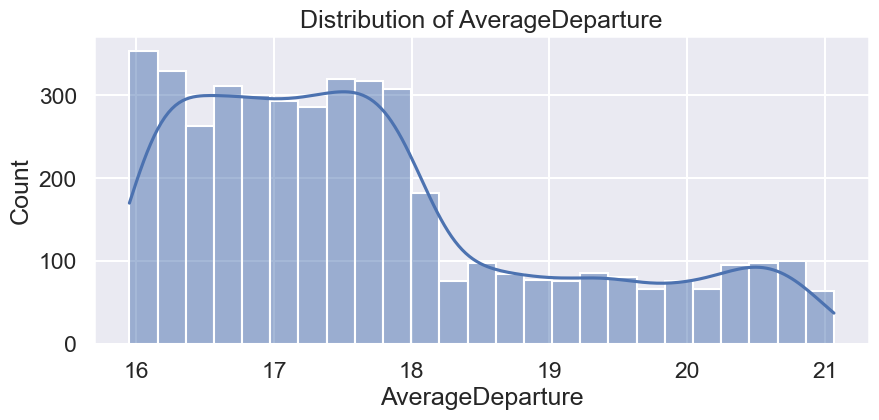

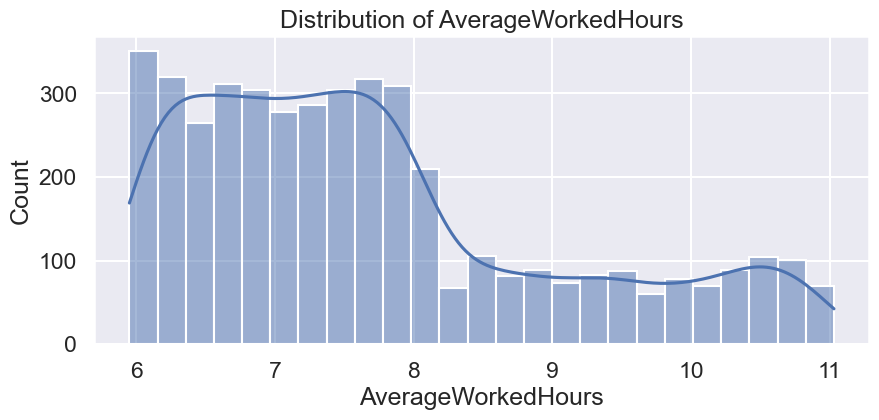

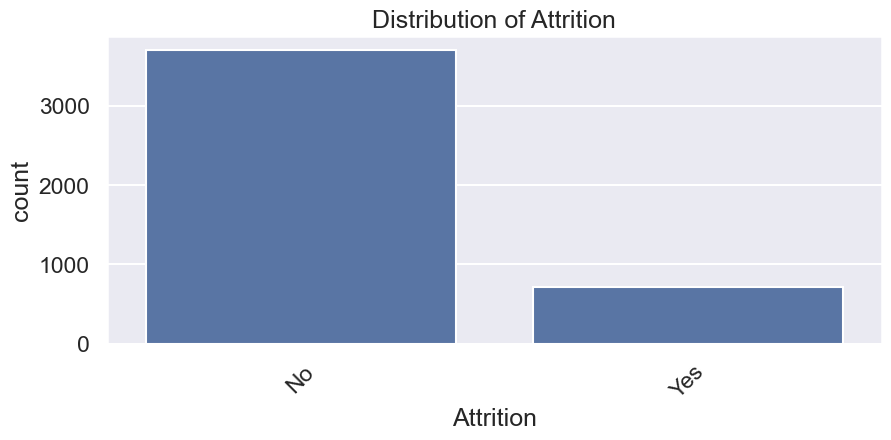

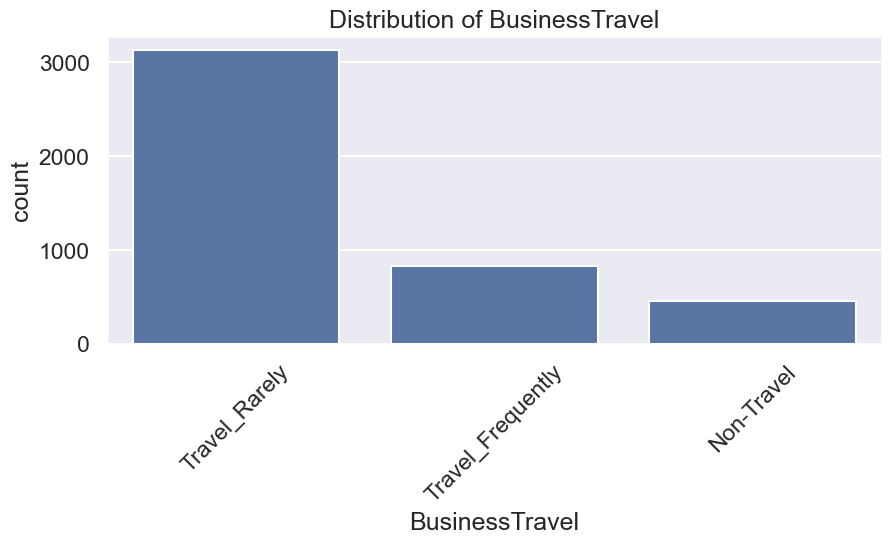

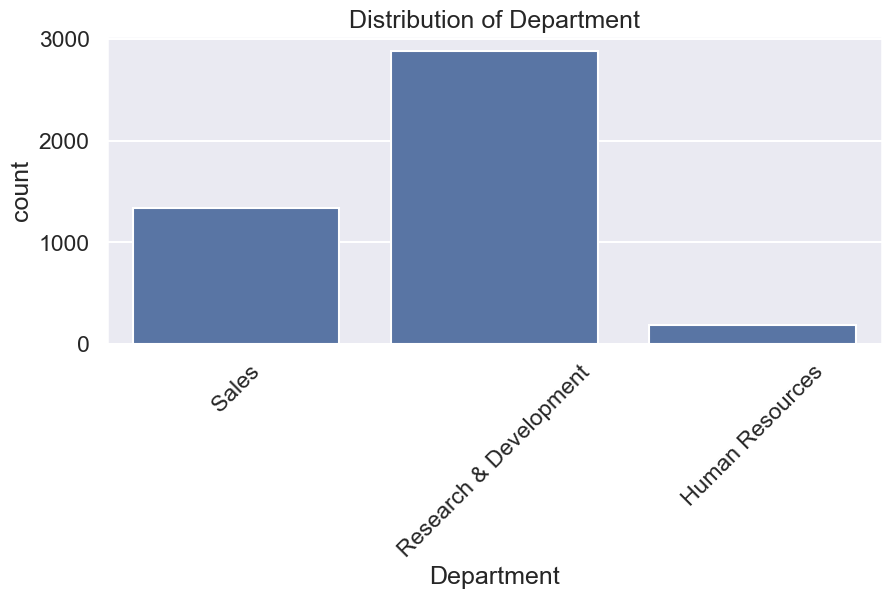

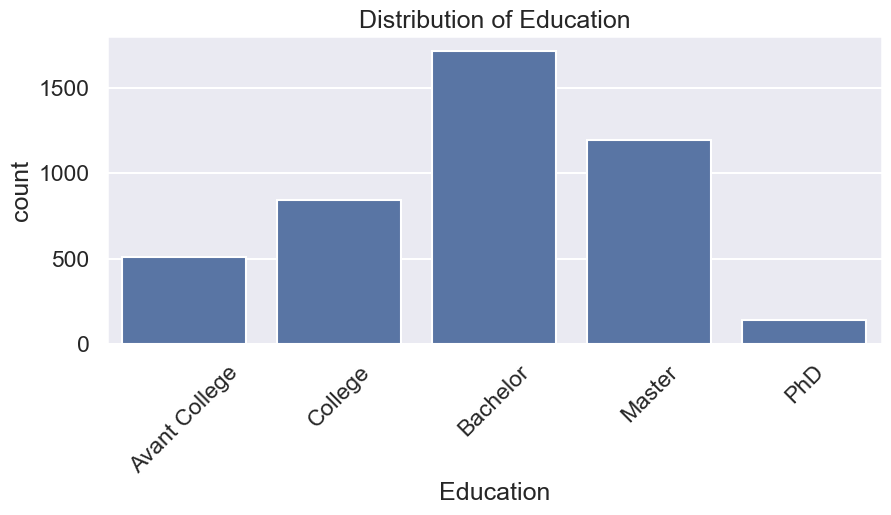

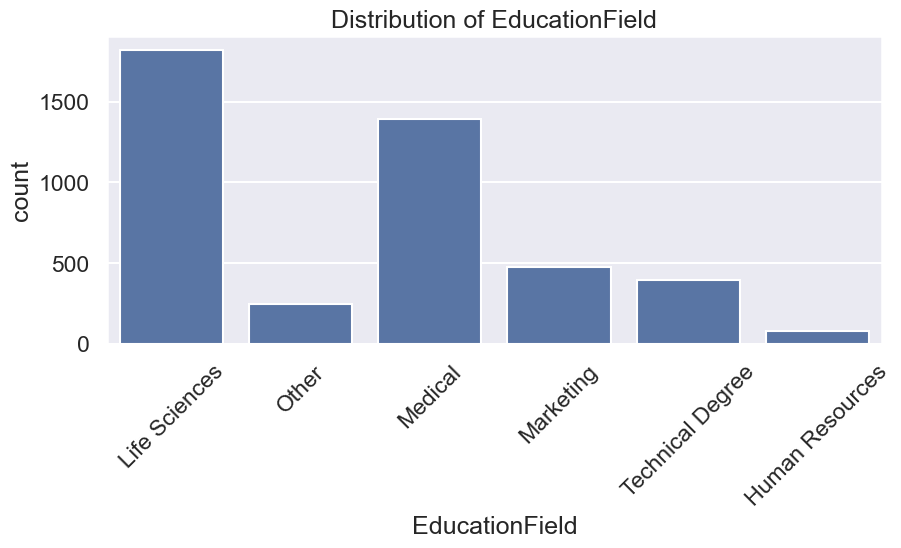

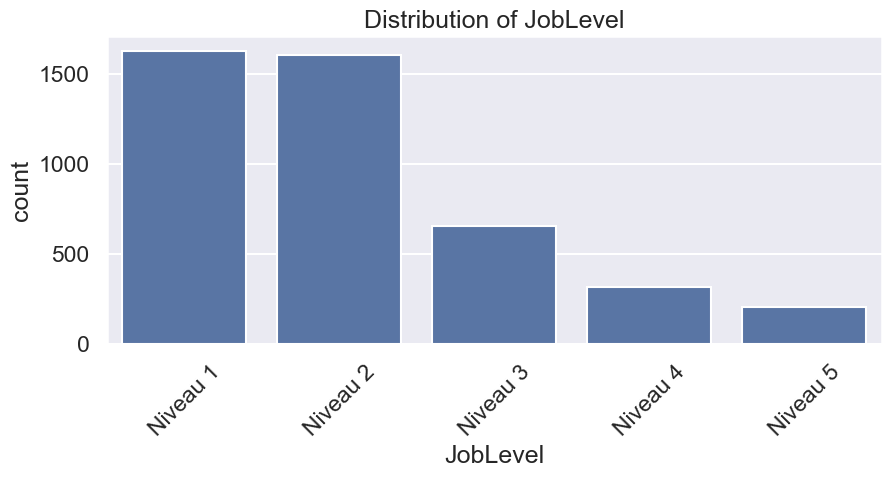

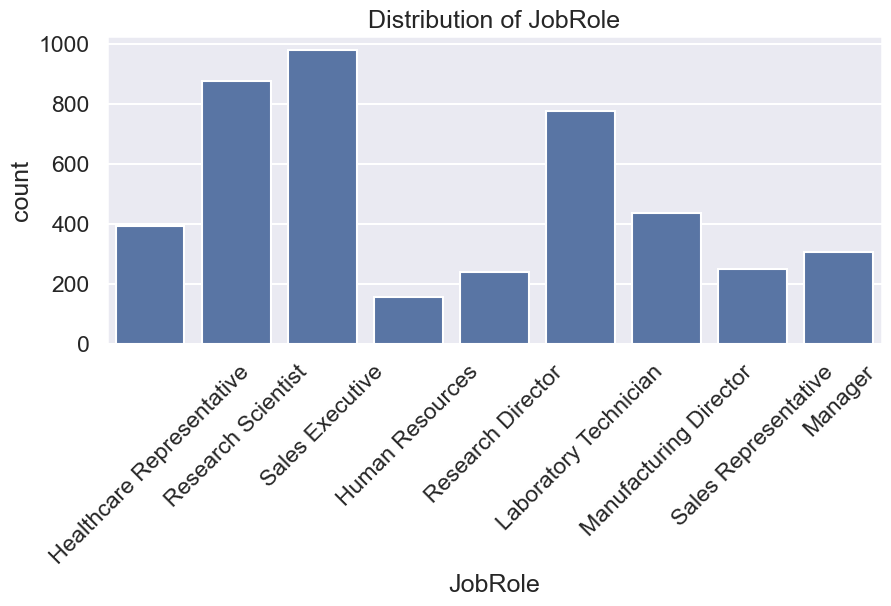

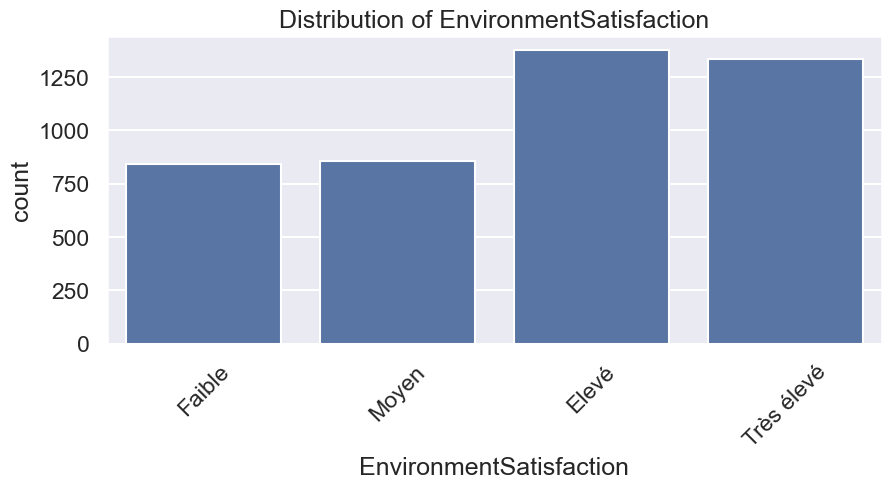

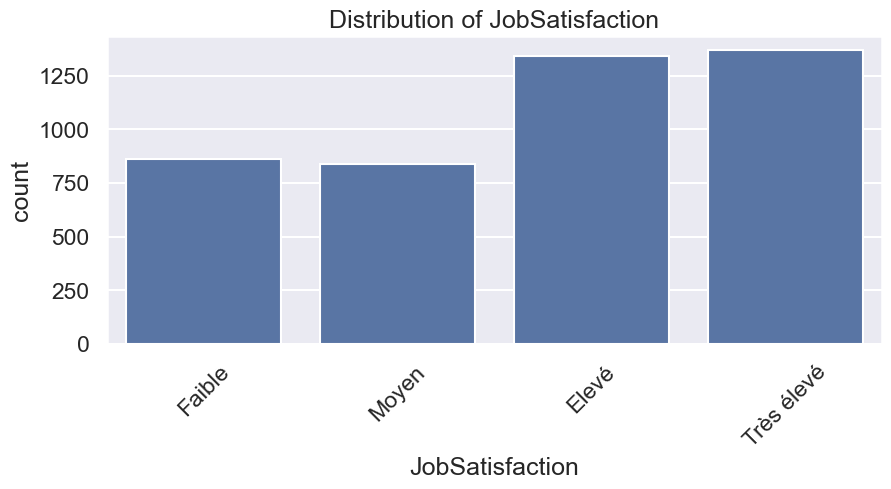

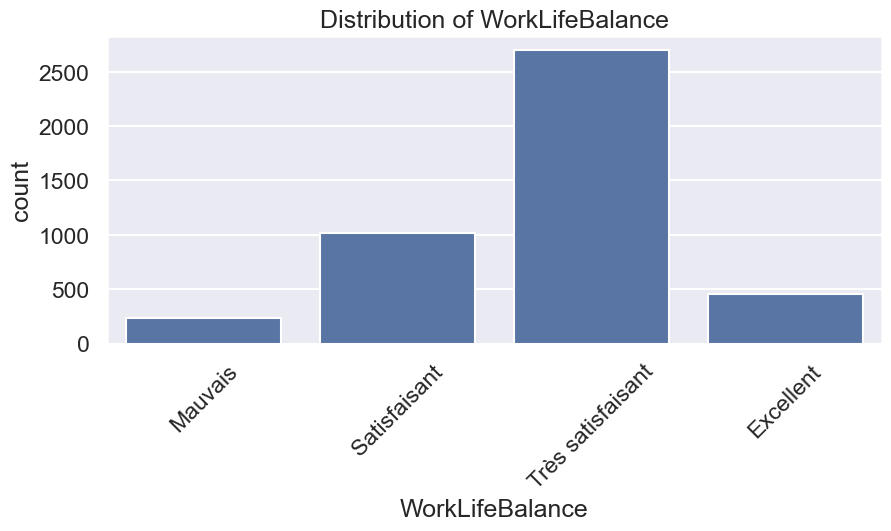

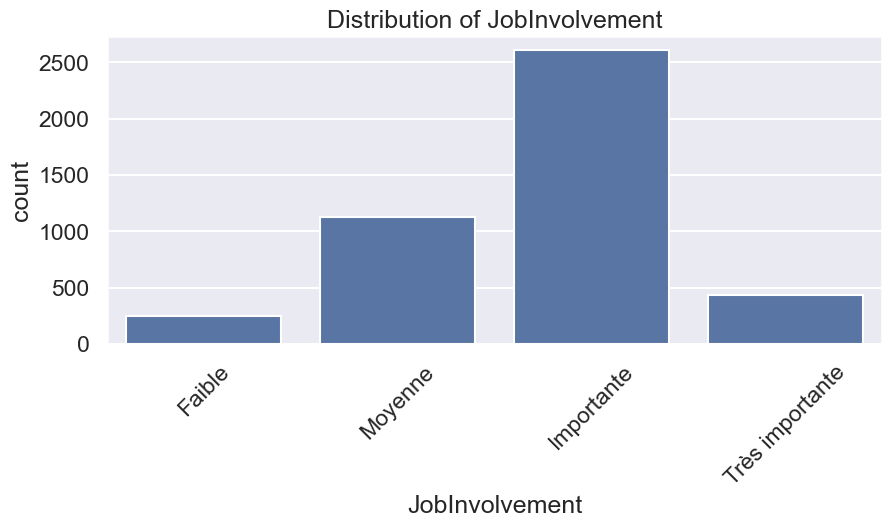

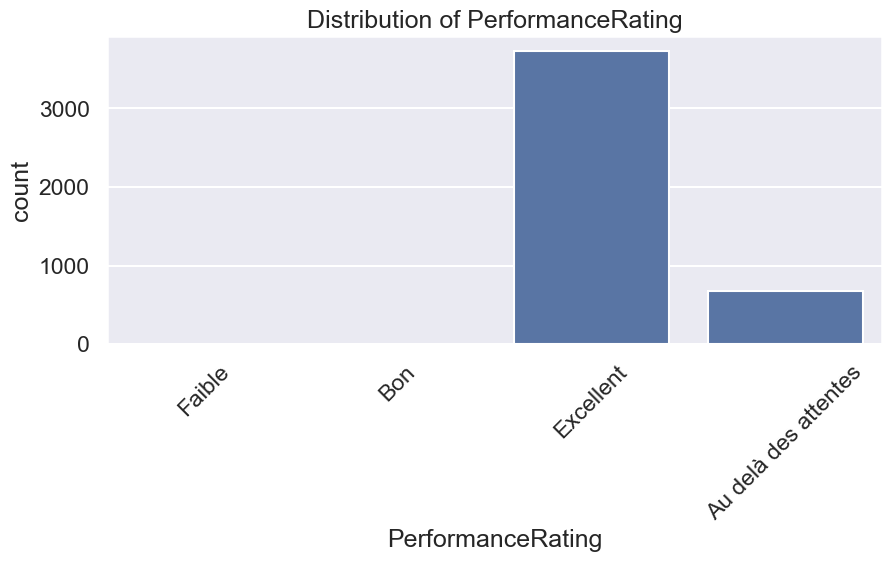

In [ ]:
education_map = {
    1: 'Avant College',
    2: 'College',
    3: 'Bachelor',
    4: 'Master',
    5: 'PhD'
}

job_map = {
    1: 'Niveau 1',
    2: 'Niveau 2',
    3: 'Niveau 3',
    4: 'Niveau 4',
    5: 'Niveau 5'
}

satisfaction_map = {
    1: 'Faible',
    2: 'Moyen',
    3: 'Elevé',
    4: 'Très élevé'
}

balance_map = {
    1: 'Mauvais',
    2: 'Satisfaisant',
    3: 'Très satisfaisant',
    4: 'Excellent'
}

involvement_map = {
    1: 'Faible',
    2: 'Moyenne',
    3: 'Importante',
    4: 'Très importante'
}

performance_map = {
    1: 'Faible',
    2: 'Bon',
    3: 'Excellent',
    4: 'Au delà des attentes'
}

data['JobLevel'] = data['JobLevel'].map(job_map)
data['Education'] = data['Education'].map(education_map)
data['EnvironmentSatisfaction'] = data['EnvironmentSatisfaction'].map(satisfaction_map)
data['JobSatisfaction'] = data['JobSatisfaction'].map(satisfaction_map)
data['WorkLifeBalance'] = data['WorkLifeBalance'].map(balance_map)
data['JobInvolvement'] = data['JobInvolvement'].map(involvement_map)
data['PerformanceRating'] = data['PerformanceRating'].map(performance_map)

category_orders = {
    'JobLevel': [job_map[i] for i in sorted(job_map)],
    'Education': [education_map[i] for i in sorted(education_map)],
    'EnvironmentSatisfaction': [satisfaction_map[i] for i in sorted(satisfaction_map)],
    'JobSatisfaction': [satisfaction_map[i] for i in sorted(satisfaction_map)],
    'WorkLifeBalance': [balance_map[i] for i in sorted(balance_map)],
    'JobInvolvement': [involvement_map[i] for i in sorted(involvement_map)],
    'PerformanceRating': [performance_map[i] for i in sorted(performance_map)]
}

data.info()

data_numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns
data_categorical_columns = data.select_dtypes(include=['object', 'str']).columns

# Univariate analysis for numerical features
for column in data_numerical_columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(data[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

# Univariate analysis for categorical features
for column in data_categorical_columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=data[column], order=category_orders.get(column, None))
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=45)
    plt.show()


In [41]:
for col in general_data_numerical_columns:
    print(col, data[col].dtype)

DistanceFromHome int64
Education int64
EmployeeID int64
JobLevel int64
MonthlyIncome int64
NumCompaniesWorked float64
PercentSalaryHike int64
StockOptionLevel int64
TotalWorkingYears float64
TrainingTimesLastYear int64
YearsAtCompany int64
YearsSinceLastPromotion int64
YearsWithCurrManager int64


In [ ]:
for columnn in general_data_numerical_columns:
    z_scores = np.abs(stats.zscore(general_data[columnn]))
    general_data = general_data[z_scores <= 3]

general_data.info()

<class 'pandas.DataFrame'>
Index: 4173 entries, 0 to 4409
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Attrition                4173 non-null   str    
 1   BusinessTravel           4173 non-null   str    
 2   Department               4173 non-null   str    
 3   DistanceFromHome         4173 non-null   int64  
 4   Education                4173 non-null   int64  
 5   EducationField           4173 non-null   str    
 6   EmployeeID               4173 non-null   int64  
 7   JobLevel                 4173 non-null   int64  
 8   JobRole                  4173 non-null   str    
 9   MonthlyIncome            4173 non-null   int64  
 10  NumCompaniesWorked       4173 non-null   float64
 11  PercentSalaryHike        4173 non-null   int64  
 12  StockOptionLevel         4173 non-null   int64  
 13  TotalWorkingYears        4173 non-null   float64
 14  TrainingTimesLastYear    4173 non-null  

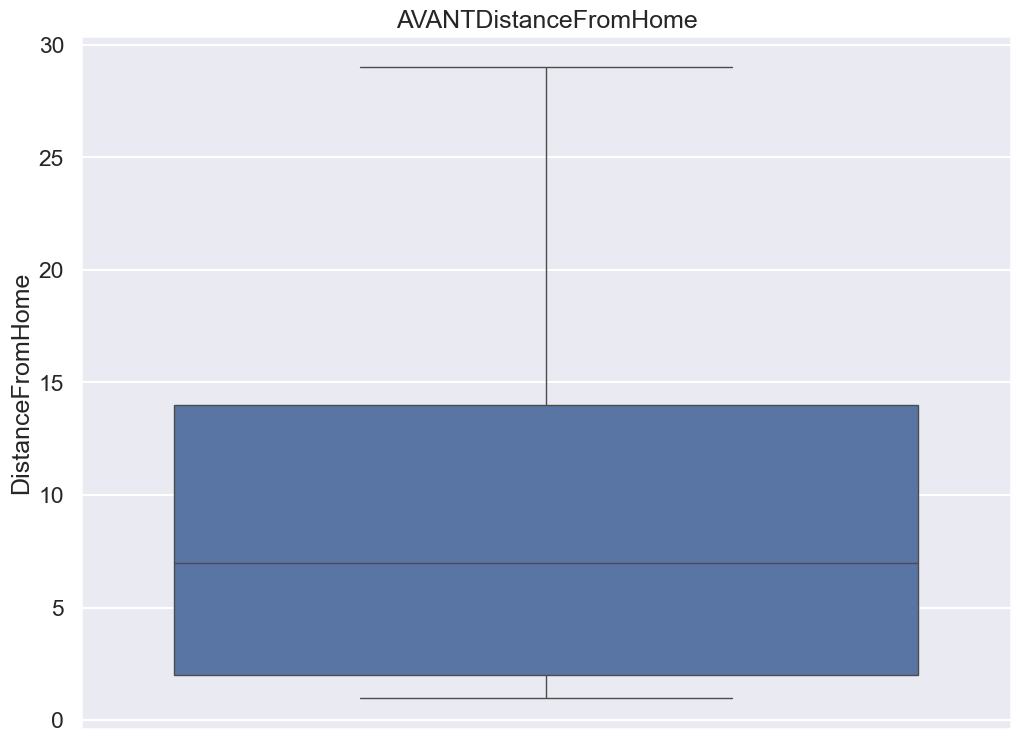

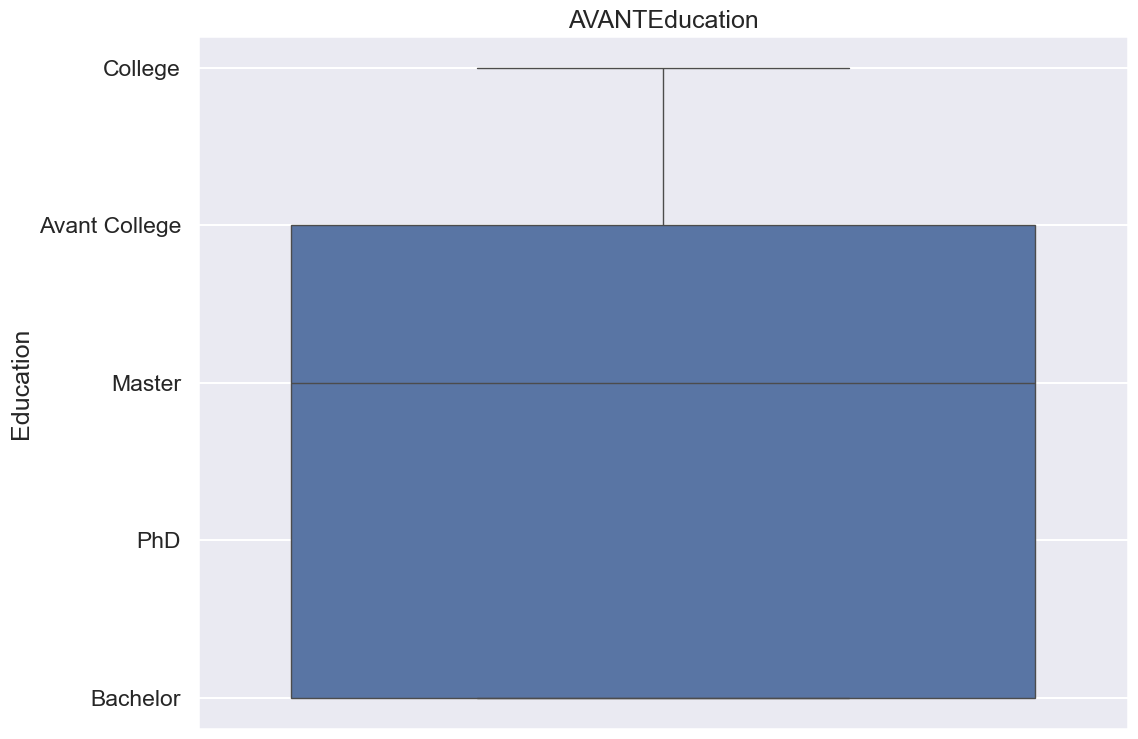

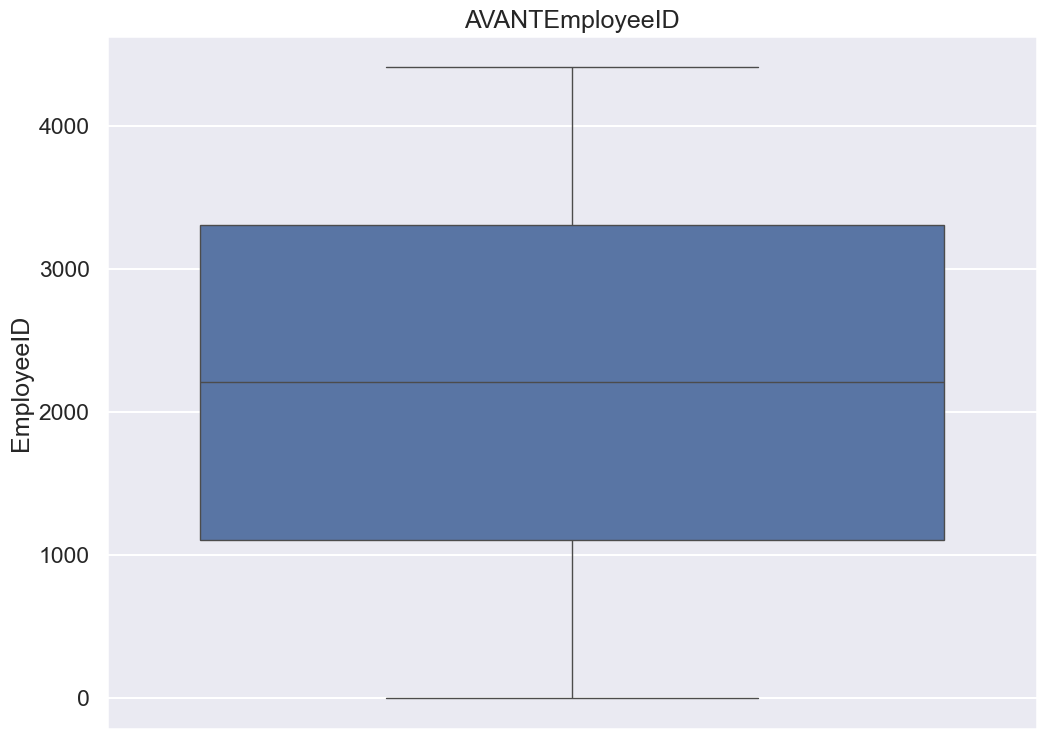

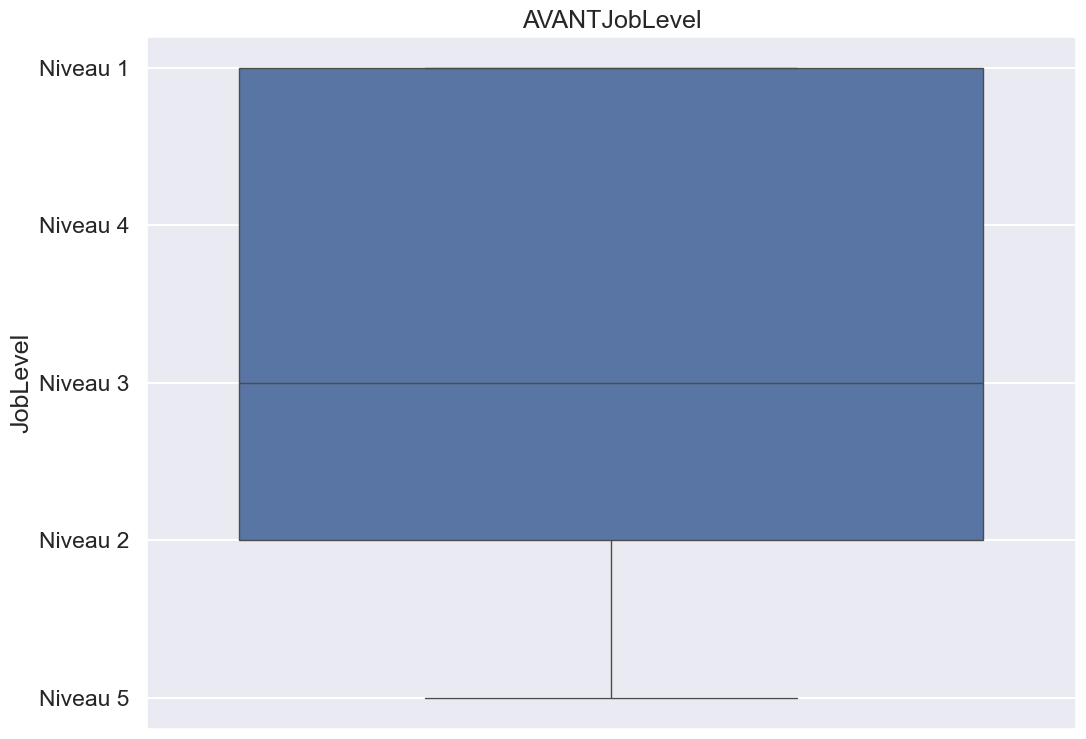

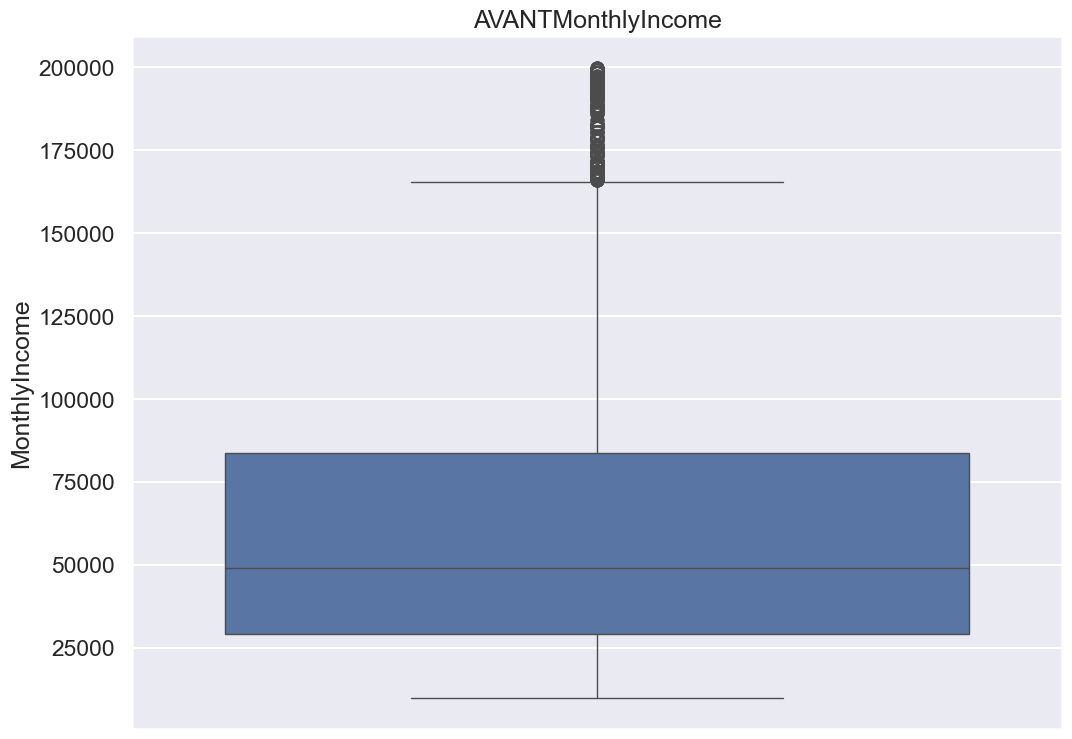

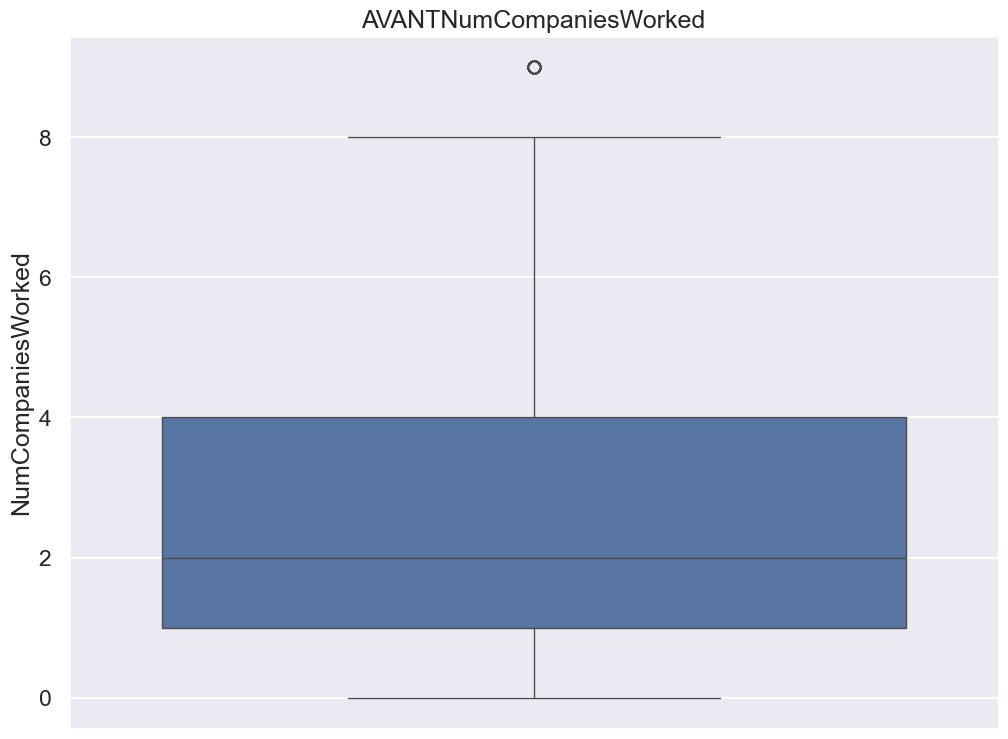

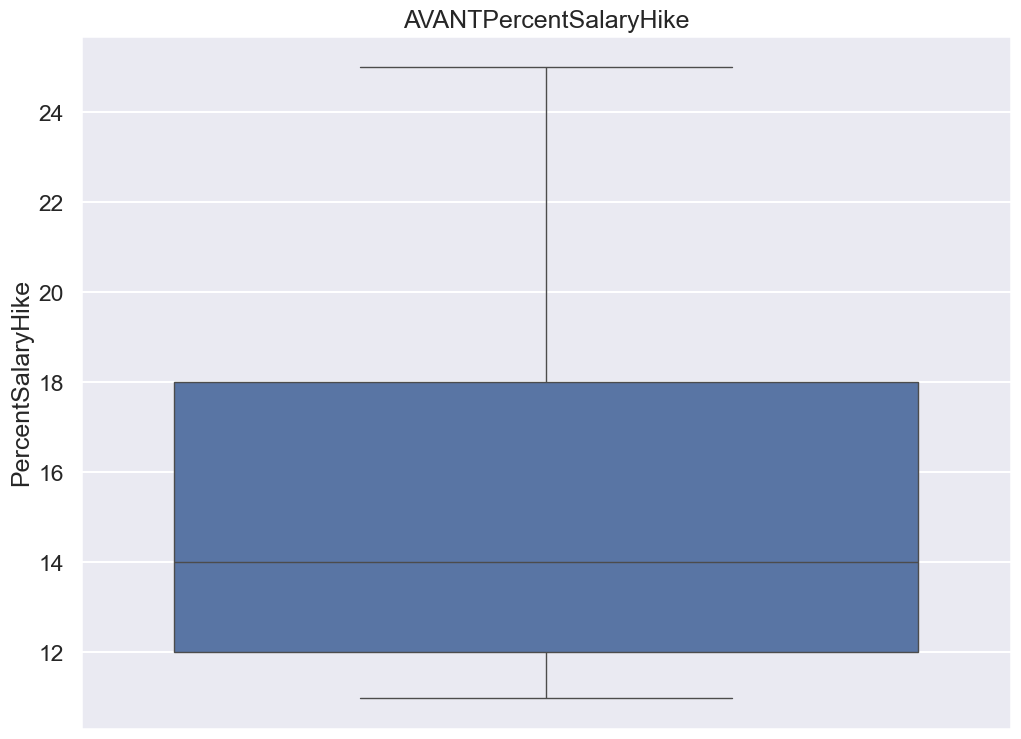

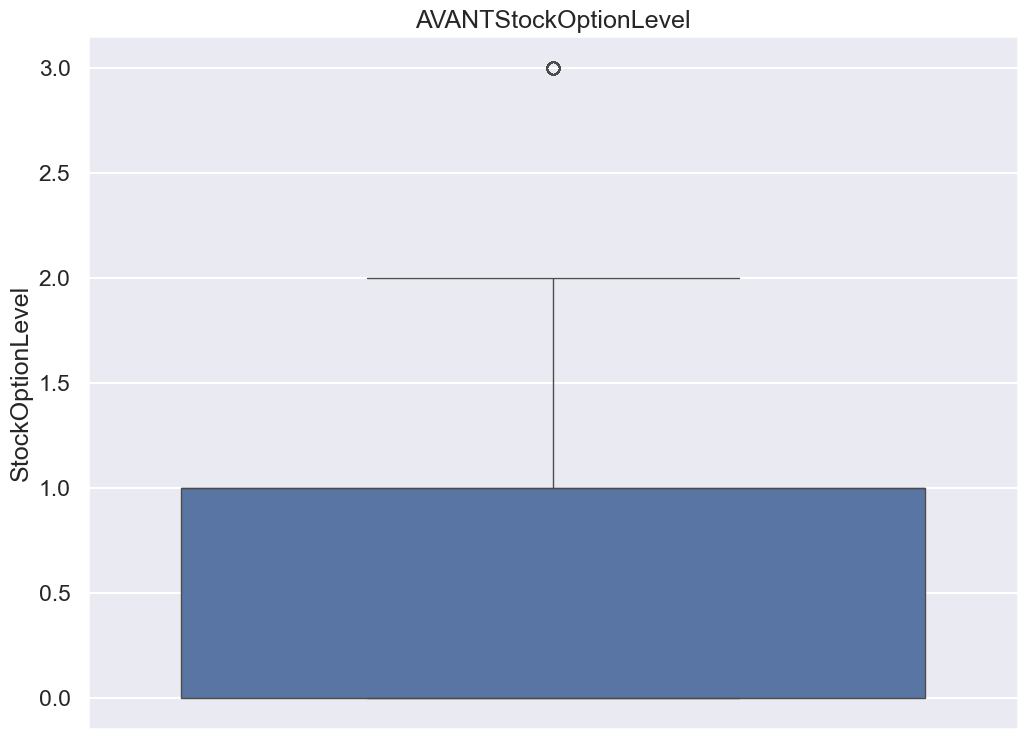

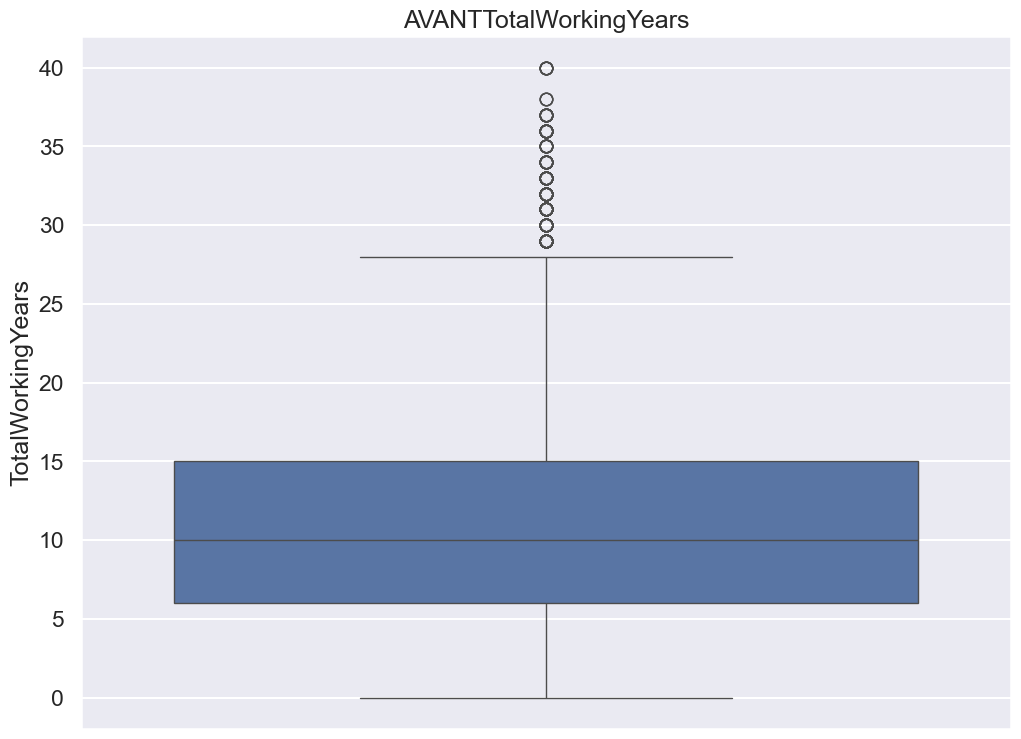

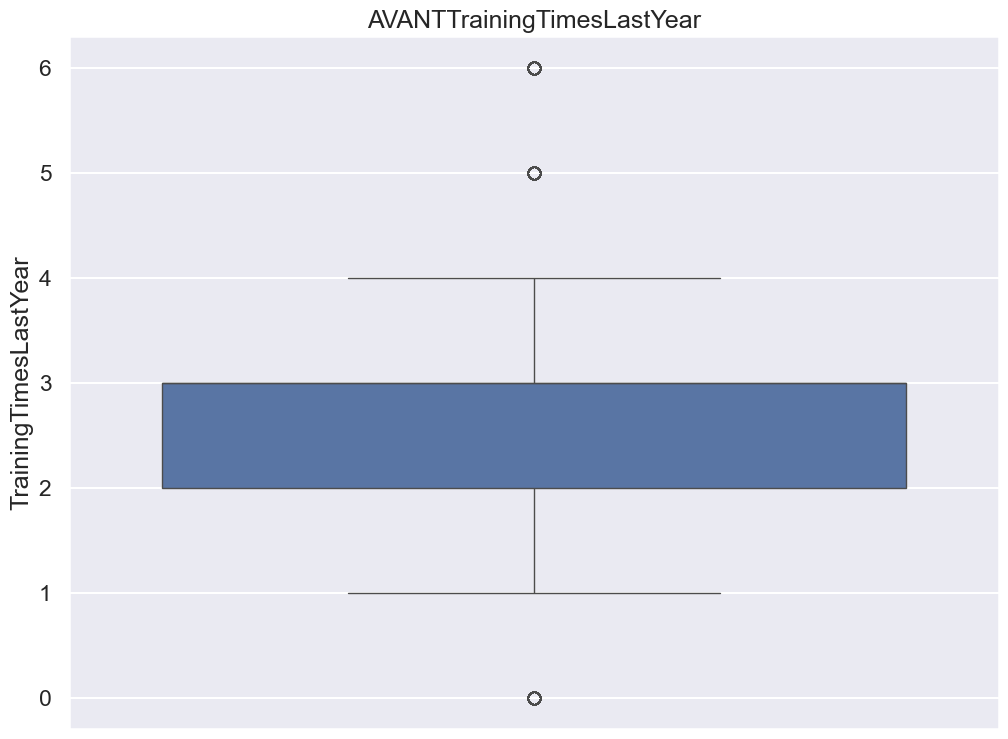

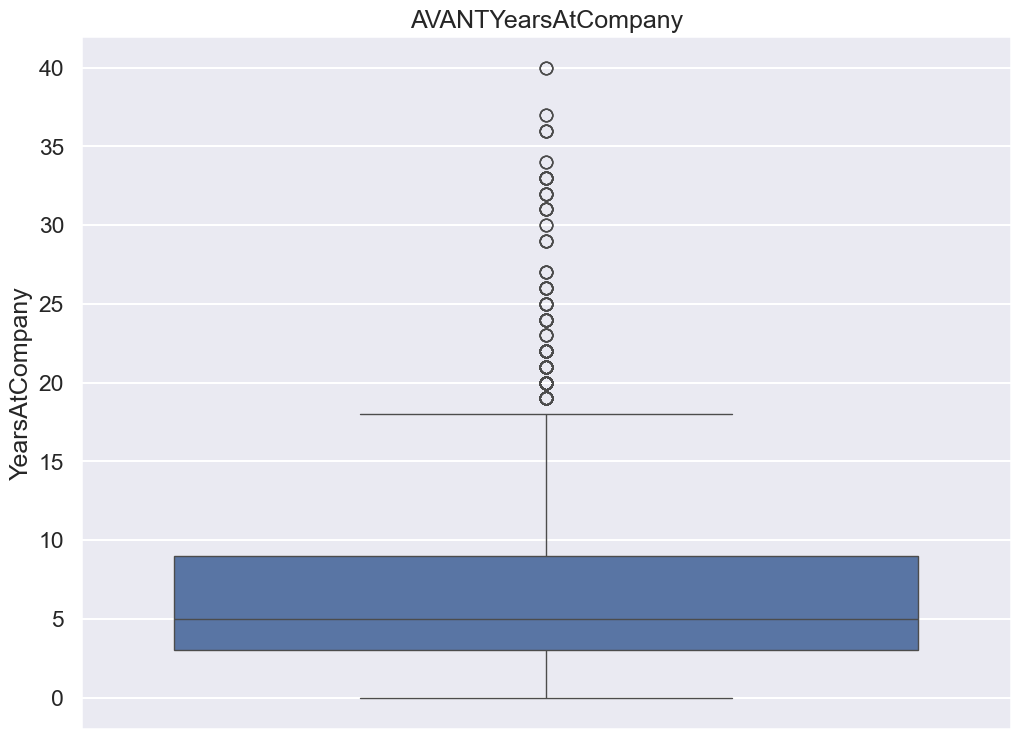

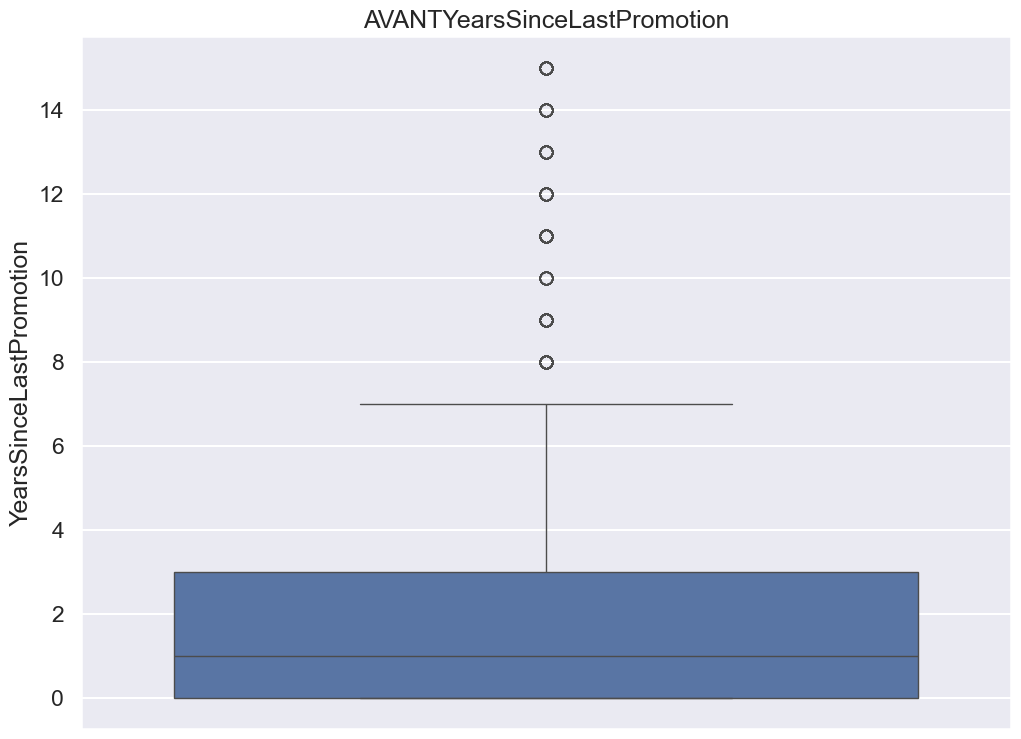

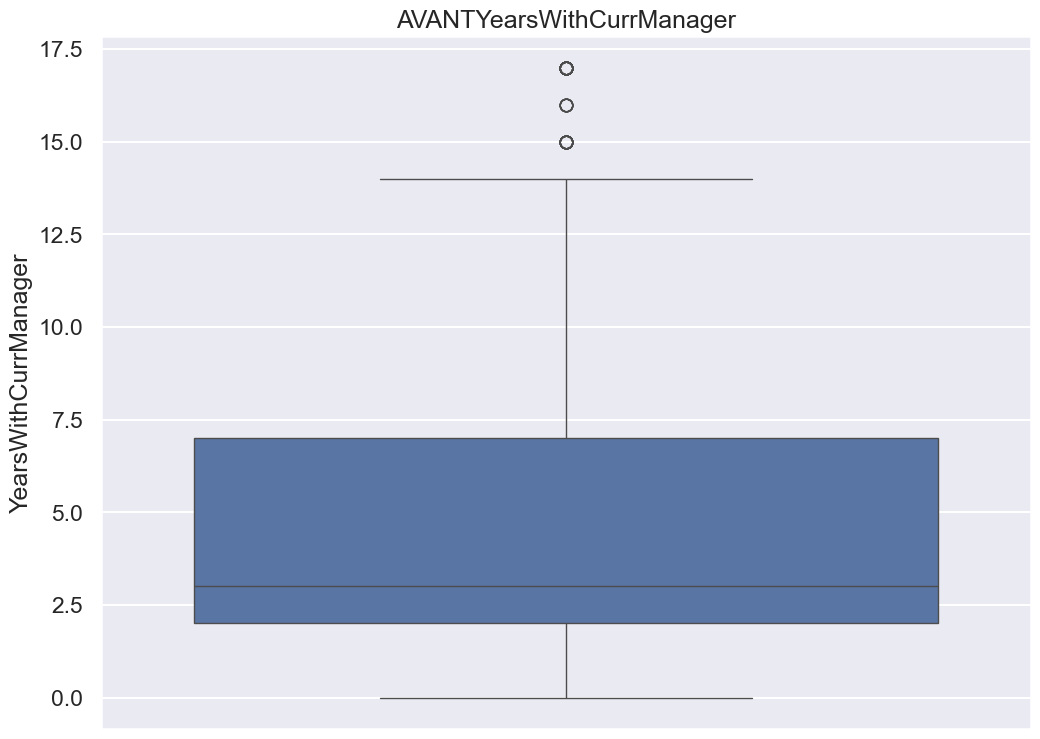

In [14]:
for col in general_data_numerical_columns:
	plt.title("AVANT"+col)
	sns.boxplot(data[col])
	plt.show()

In [42]:
for col in general_data_numerical_columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data = data[(data[col] >= lower) & (data[col] <= upper)]

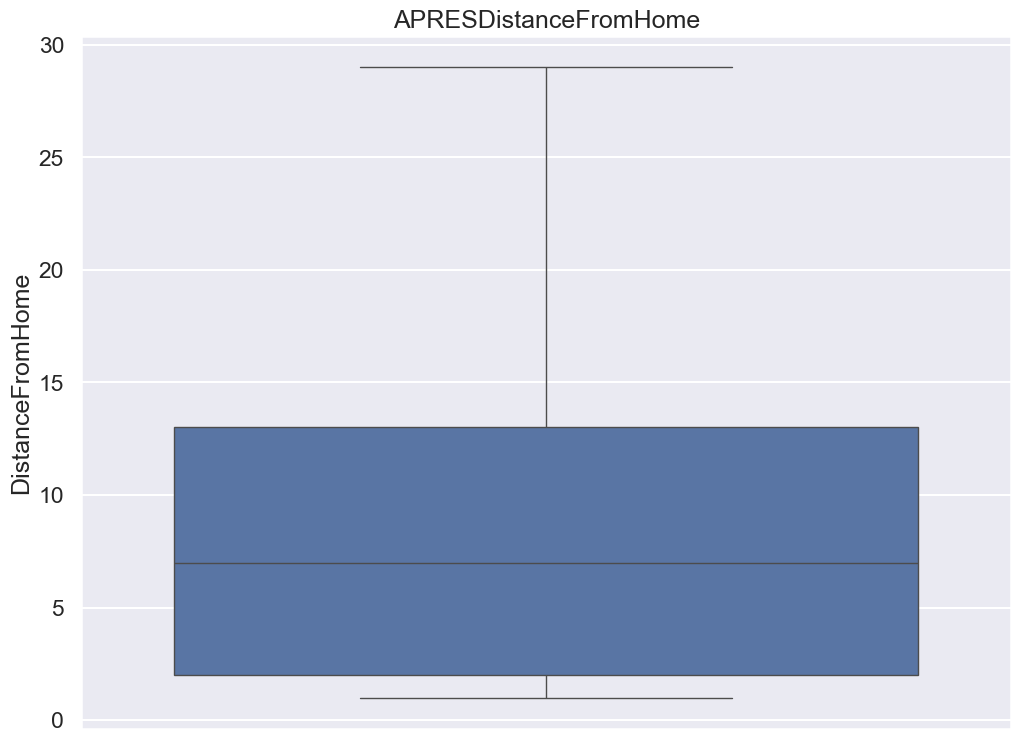

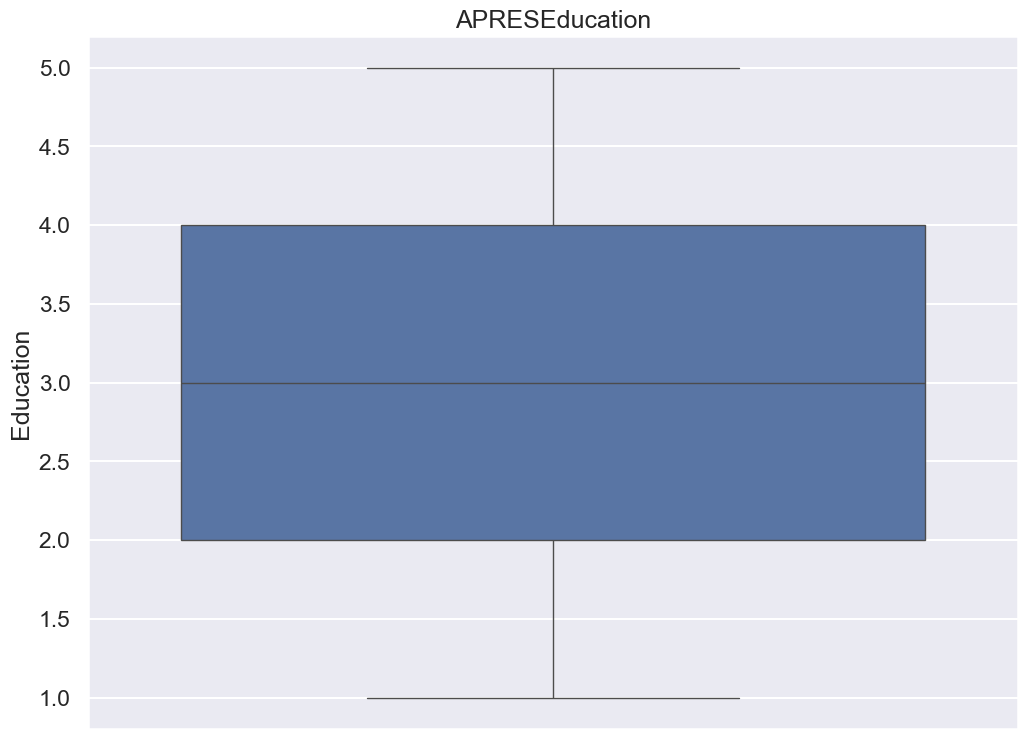

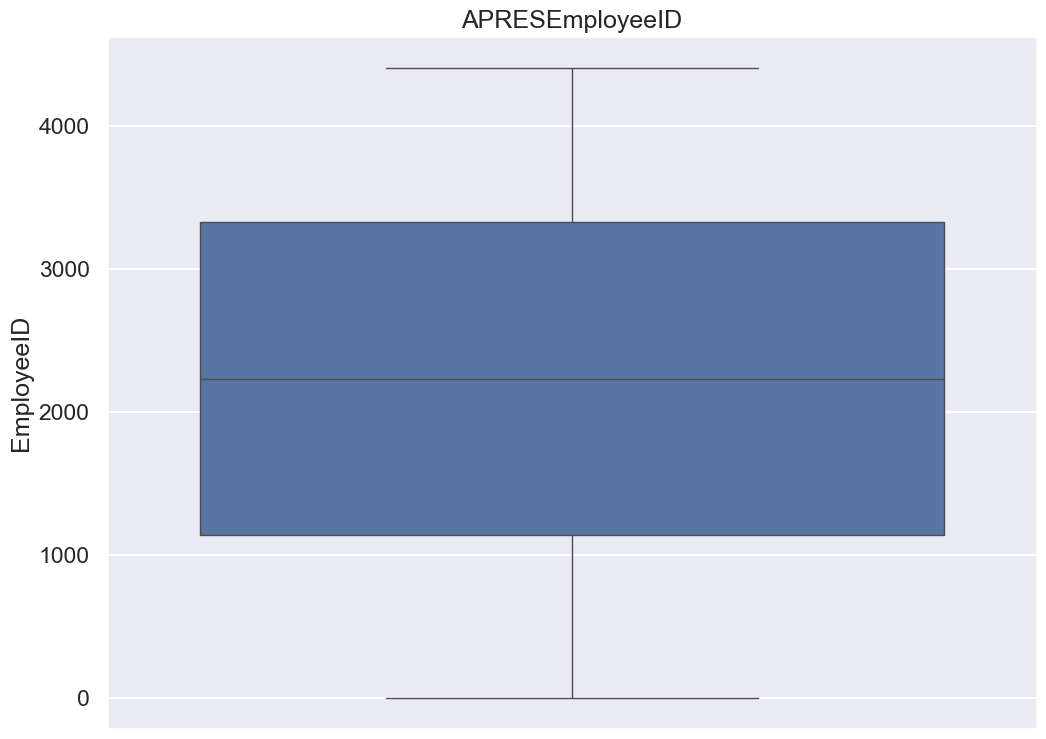

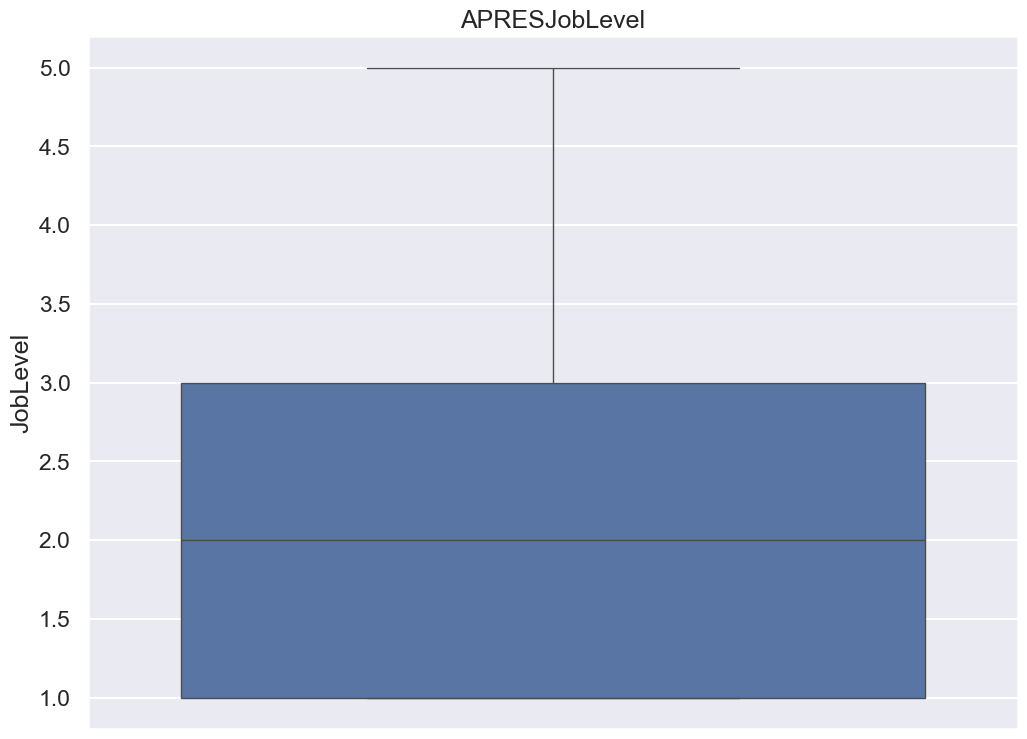

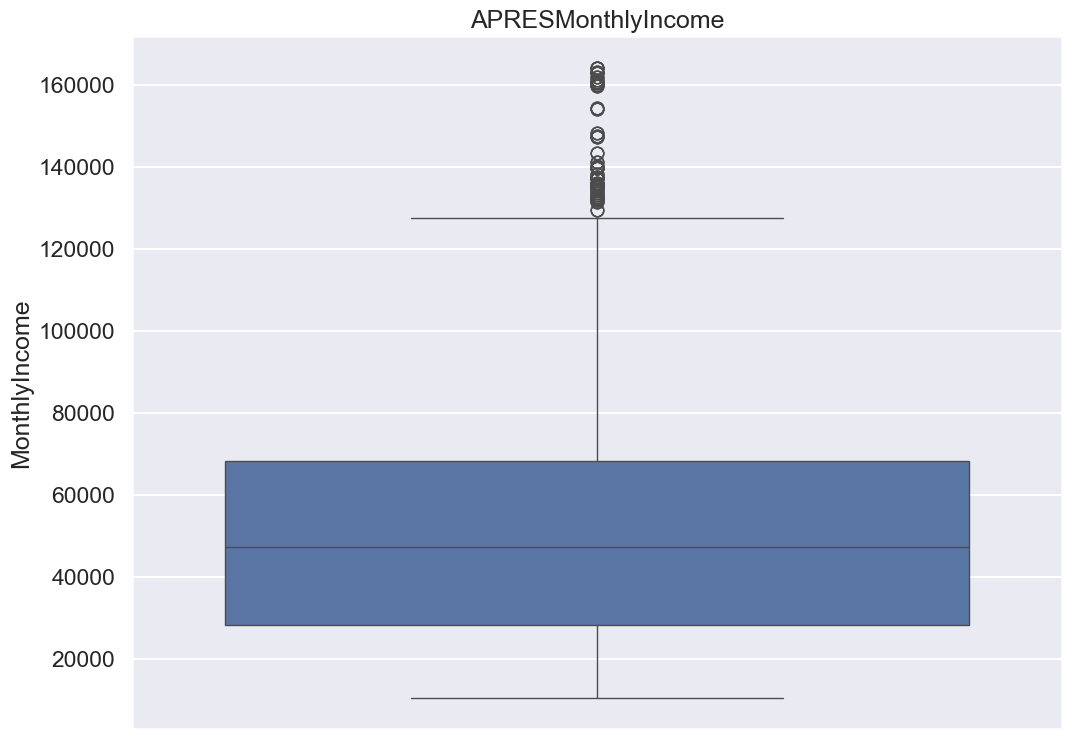

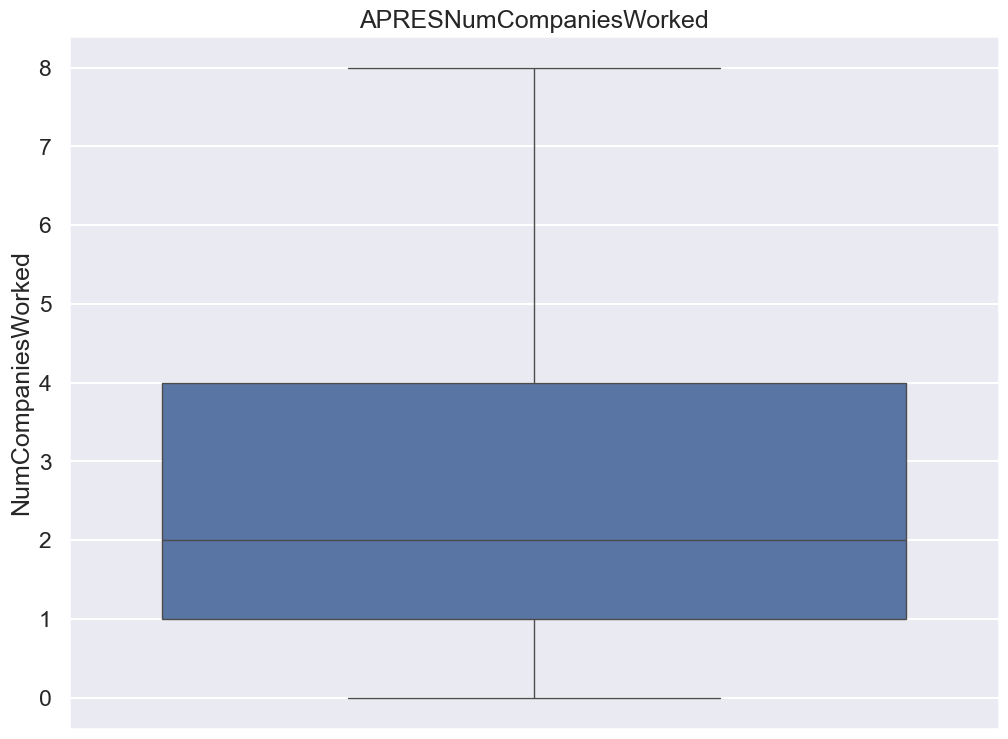

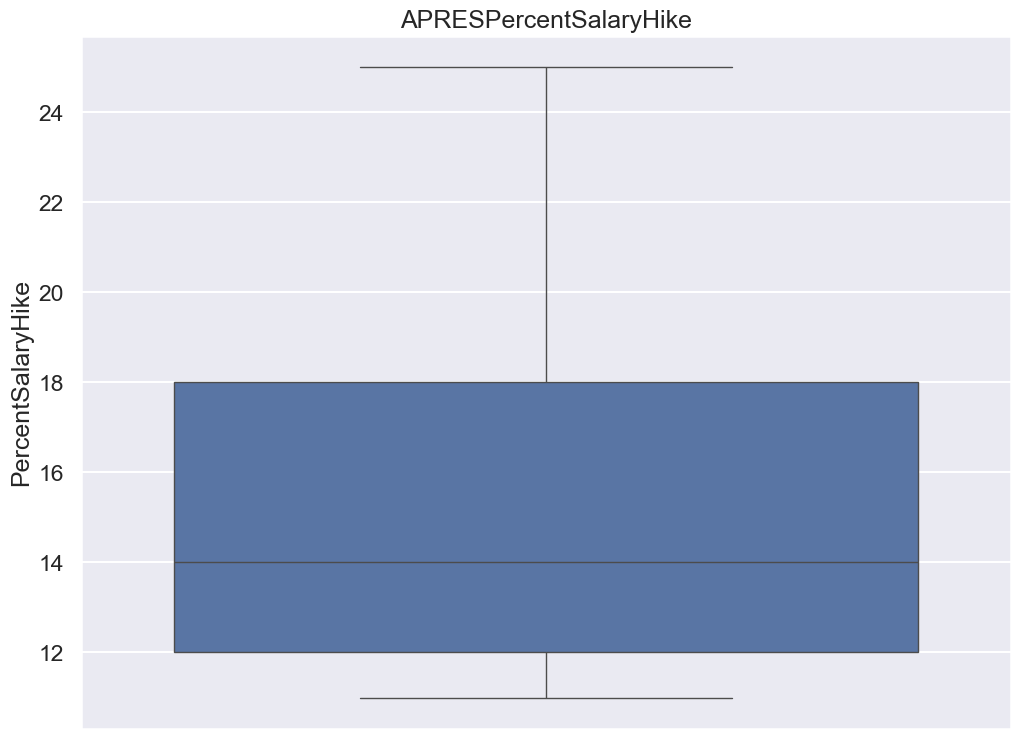

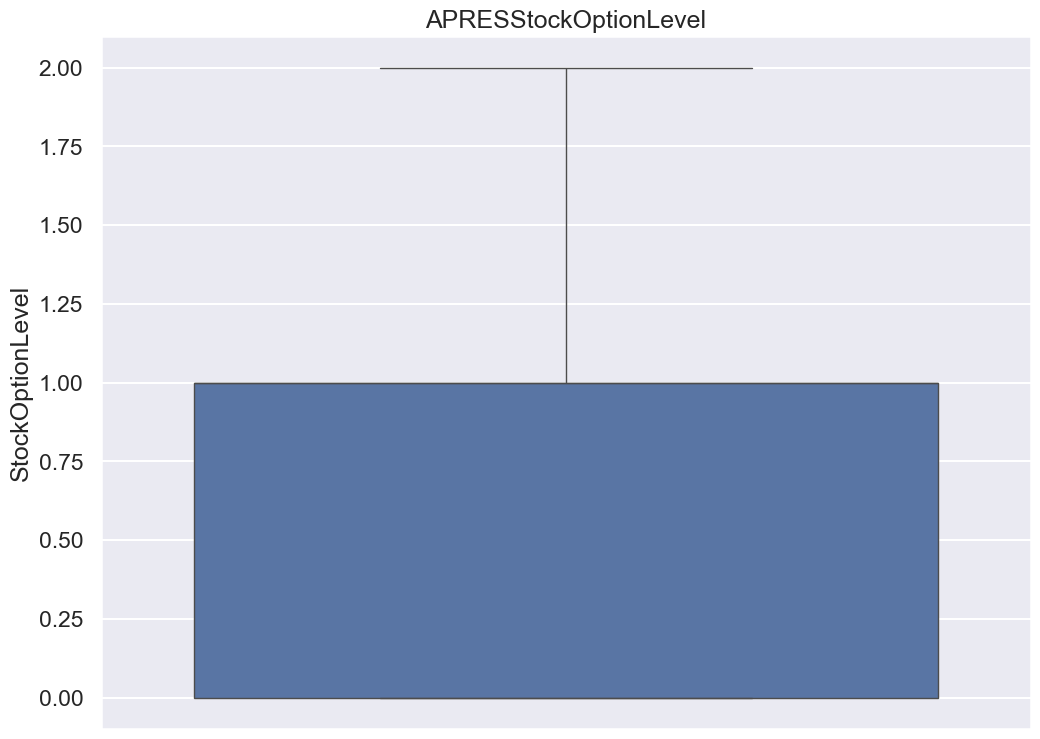

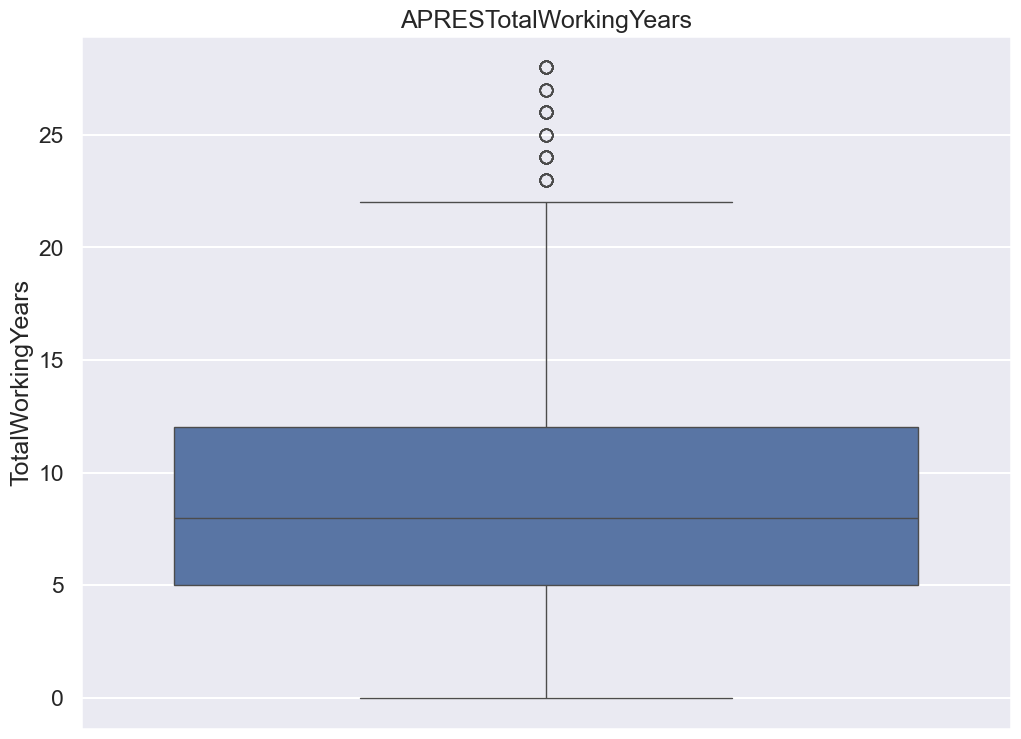

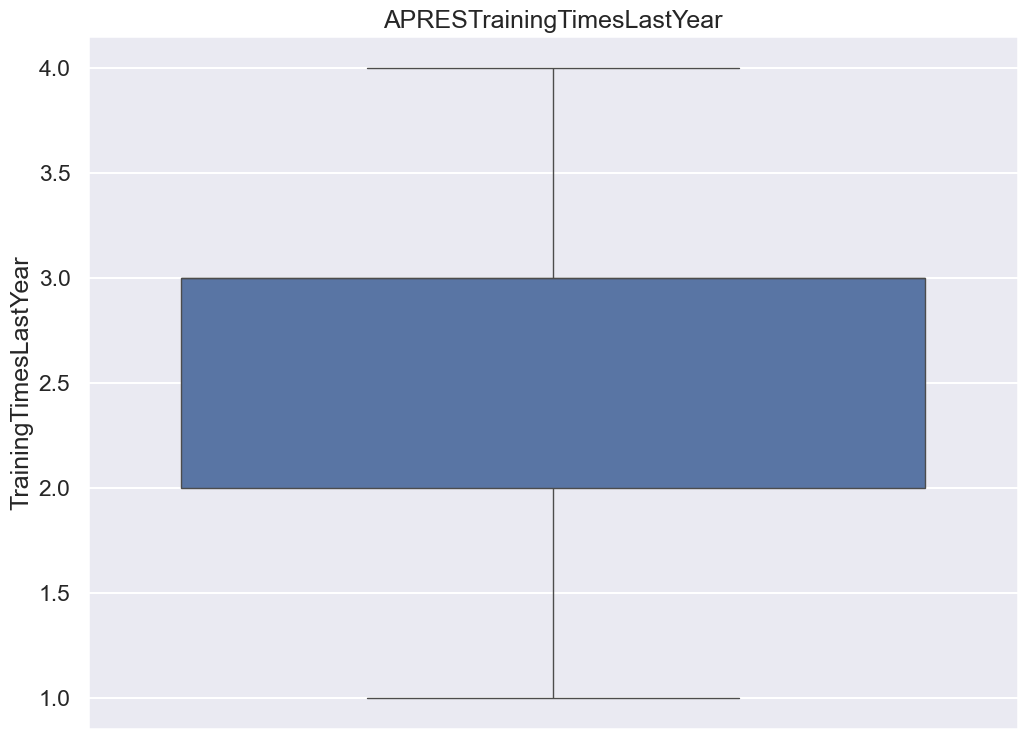

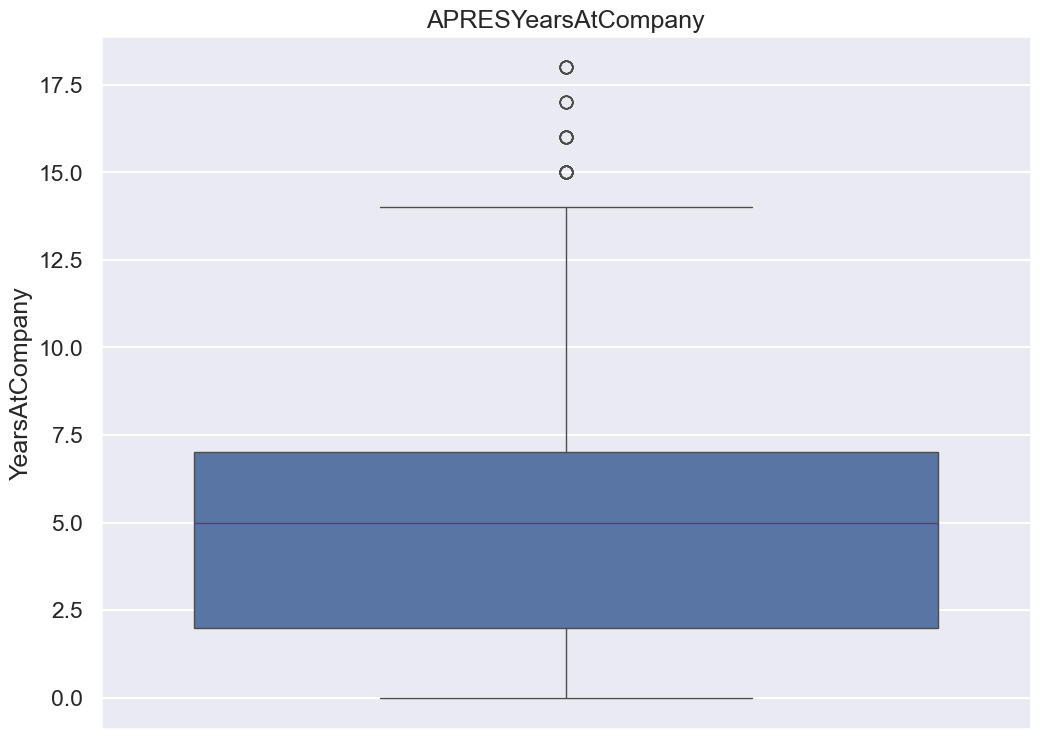

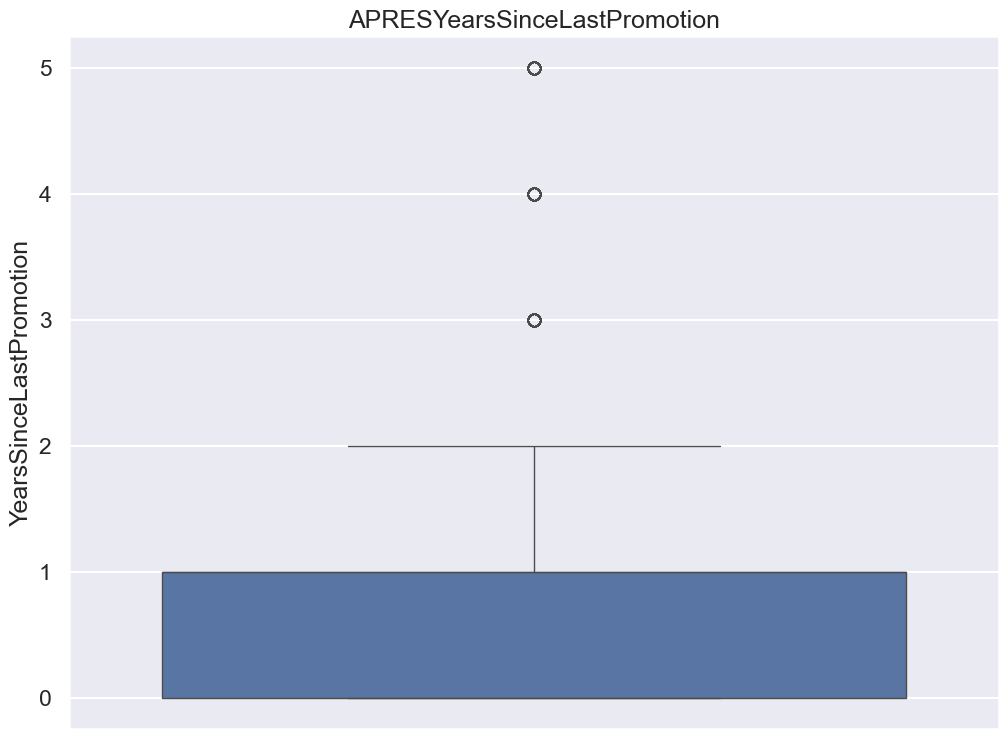

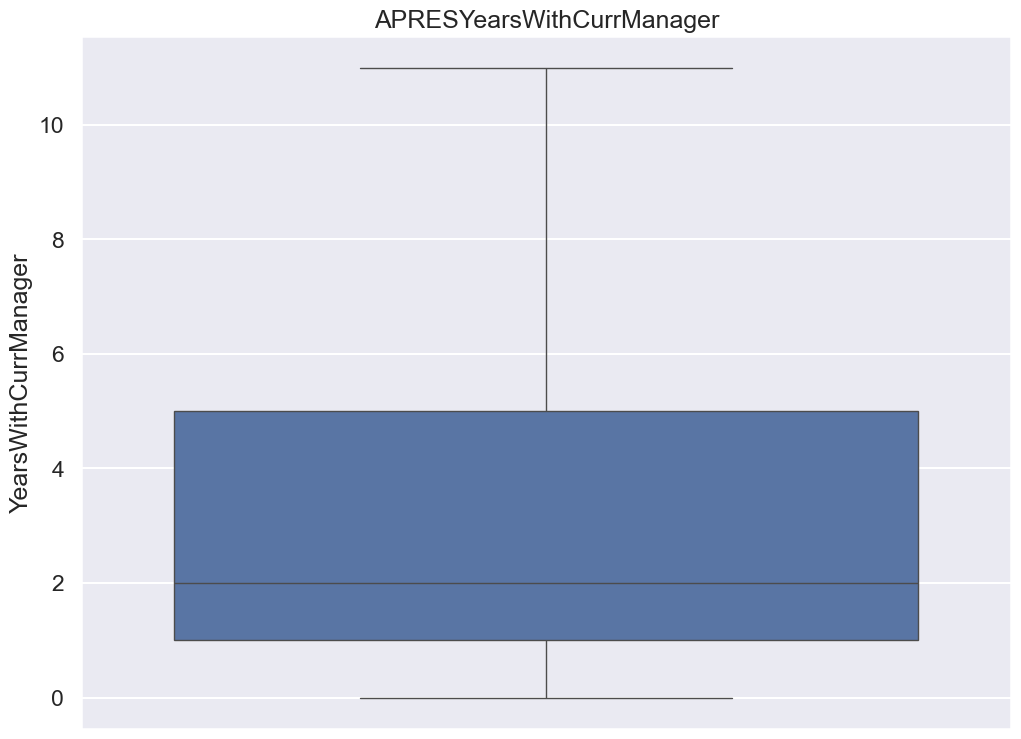

In [43]:
for col in general_data_numerical_columns:
	plt.title("APRES"+col)
	sns.boxplot(data[col])
	plt.show()